In [16]:
import sys
from pathlib import Path

# Ensure repo root is on the path so anp_emulator and train_anp_emulator are importable
sys.path.insert(0, str(Path('..').resolve()))


In [24]:
from pathlib import Path
from types import SimpleNamespace
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from anp_emulator import Emulator
from train_anp_emulator import build_tasks, split_tasks, resolve_profile_file, load_theta_table, filter_tasks_by_mass_quantile


In [25]:
# ── Mode selector ─────────────────────────────────────────────────────────────
# SINGLE emulator (original behaviour):
#   Set QUANTILE_RUN_DIRS = None and point RUN_DIR to a run directory.
#
# MULTI-QUANTILE emulators (5 separate emulators trained on mass slices):
#   Set RUN_DIR = None and fill in QUANTILE_RUN_DIRS with the 5 run dirs
#   produced by run_train_mass_quantiles.sh.  The notebook will route each
#   halo's prediction to the emulator that was trained on that mass slice.

RUN_DIR = Path('../anp_training_runs/anp_all_profiles_20260325_175639')  # single emulator
RUN_DIR = Path('../anp_training_runs/anp_all_profiles_20260403_105317')  # single emulator

# RUN_DIR = None

QUANTILE_RUN_DIRS = None   # single-emulator mode
# QUANTILE_RUN_DIRS = {
#     0: Path('../anp_training_runs/anp_all_profiles_hq0of5_20260402_212405'),
#     1: Path('../anp_training_runs/anp_all_profiles_hq1of5_20260402_212405'),
#     2: Path('../anp_training_runs/anp_all_profiles_hq2of5_20260402_212405'),
#     3: Path('../anp_training_runs/anp_all_profiles_hq3of5_20260402_212405'),
#     4: Path('../anp_training_runs/anp_all_profiles_hq4of5_20260402_212405'),
# }

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Load emulator(s) ───────────────────────────────────────────────────────────
MULTI_QUANTILE_MODE = (QUANTILE_RUN_DIRS is not None)

if MULTI_QUANTILE_MODE:
    missing = [i for i, d in QUANTILE_RUN_DIRS.items() if not Path(d).exists()]
    if missing:
        raise FileNotFoundError(
            f'Missing quantile run dirs for quantile(s) {missing}.\n'
            'Fill in QUANTILE_RUN_DIRS above after running run_train_mass_quantiles.sh.'
        )
    emulators = {qi: Emulator.from_run_dir(d, device=DEVICE) for qi, d in sorted(QUANTILE_RUN_DIRS.items())}
    # For backward compatibility: point `emu` at the highest-mass quantile
    # (most relevant for observed high-mass clusters).
    last_qi = max(emulators.keys())
    emu = emulators[last_qi]
    print(f'Loaded {len(emulators)} quantile emulators (MULTI mode).')
    for qi, e in emulators.items():
        print(f'  Q{qi}: {QUANTILE_RUN_DIRS[qi].name}  fields={e.available_fields()}')
else:
    if RUN_DIR is None or not Path(RUN_DIR).exists():
        raise FileNotFoundError(f'Run directory not found: {RUN_DIR}')
    emu = Emulator.from_run_dir(RUN_DIR, device=DEVICE)
    emulators = {0: emu}  # single-emulator fallback for unified downstream code
    print(f'Loaded single emulator: {RUN_DIR}')
    print('Available fields:', emu.available_fields())


Loaded single emulator: ../anp_training_runs/anp_all_profiles_20260403_105317
Available fields: ['gas_density', 'temperature', 'pressure', 'metallicity']


In [26]:
# ── Mass-routing setup ────────────────────────────────────────────────────────
# Supports two quantile_info.json formats:
#   proxy = "halo_individual_logm"  — new halo-level runs (hq0/hq1/hq2)
#     keys: q_lo, q_hi, all_edges, n_halos, n_families
#   proxy = "family_*"              — old family-level runs (legacy, deprecated)
#     keys: q_lo, q_hi, n_families
#
# route_halo_to_quantile(log10_mass) routes each halo's log10(M) to the correct
# emulator.  In MULTI_QUANTILE_MODE=False, all halos go to emulators[0].
MULTI_QUANTILE_MODE = False

import warnings
if MULTI_QUANTILE_MODE:
    quantile_edges = {}
    for qi, run_dir in QUANTILE_RUN_DIRS.items():
        info_path = Path(run_dir) / 'quantile_info.json'
        if not info_path.exists():
            raise FileNotFoundError(f'quantile_info.json not found in {run_dir}.')
        with open(info_path) as f:
            info = json.load(f)
        q_lo = float(info['q_lo'])
        q_hi = float(info['q_hi'])
        proxy_label = info.get('proxy', 'unknown')
        n_units = info.get('n_halos', info.get('n_families', '?'))
        unit_label = 'halos' if 'halo' in proxy_label else 'families'
        quantile_edges[qi] = (q_lo, q_hi)

        if 'halo_individual' in proxy_label:
            print(f"  Q{qi}: log10(M) \u2208 [{q_lo:.3f}, {q_hi:.3f}]  ({n_units} {unit_label})")
        else:
            print(f"  Q{qi}: [{q_lo:.3f}, {q_hi:.3f}]  ({n_units} {unit_label}, proxy={proxy_label})")
            if 'median' in proxy_label:
                warnings.warn(
                    f"Q{qi} was trained with median-mass proxy (family-level) — "
                    "not a true halo-mass-specialist emulator!  "
                    "Retrain with: bash run_train_mass_quantiles.sh",
                    UserWarning)

    _sorted_edges = sorted(quantile_edges.items(), key=lambda kv: kv[1][0])
    _n_q = len(quantile_edges)
    _top_qi = max(quantile_edges.keys())

    def route_halo_to_quantile(log10_mass):
        """Route each halo to its quantile emulator by individual halo log10(M)."""
        log10_mass = np.asarray(log10_mass, dtype=np.float64)
        qi_out = np.full(log10_mass.shape, _top_qi, dtype=int)
        for qi, (q_lo, q_hi) in _sorted_edges:
            if qi < _top_qi:
                mask = (log10_mass >= q_lo) & (log10_mass < q_hi)
            else:
                mask = log10_mass >= q_lo
            qi_out[mask] = qi
        qi_out[log10_mass < _sorted_edges[0][1][0]] = _sorted_edges[0][0]
        return qi_out

    print(f'\nRouting function ready ({_n_q} quantiles).')
    print('Halos with log10(M) < {:.3f} -> Q{}, >= {:.3f} -> Q{}'.format(
        _sorted_edges[0][1][0], _sorted_edges[0][0],
        _sorted_edges[-1][1][0], _sorted_edges[-1][0]))
else:
    quantile_edges = {0: (-np.inf, np.inf)}
    def route_halo_to_quantile(log10_mass):
        return np.zeros(np.asarray(log10_mass).shape, dtype=int)
    print('Single-emulator mode.')


Single-emulator mode.


In [27]:
# CV-seed validation setup across all snapshots/redshifts used in training.
from pathlib import Path
import re

CV_PROFILE_DIR = Path('/mnt/home/mlee1/ceph/Profiles_cy_test/')
CV_FIELDS = ['pressure', 'temperature', 'gas_density']
CV_MASS_CUT = 1e13
CV_NSAMPLES = 30

if not CV_PROFILE_DIR.exists():
    raise FileNotFoundError(f'Profile directory not found: {CV_PROFILE_DIR}')


def _parse_snapshot_redshifts_text(mapping_text):
    out = {}
    for chunk in str(mapping_text).split(','):
        chunk = chunk.strip()
        if not chunk:
            continue
        snap_str, sep, z_str = chunk.partition(':')
        if sep != ':':
            continue
        out[int(snap_str.strip())] = float(z_str.strip())
    return out


def _resolve_training_snaps_and_redshifts(run_args):
    snaps = []

    if isinstance(run_args.get('resolved_snapnums', None), (list, tuple)):
        snaps = [int(s) for s in run_args['resolved_snapnums']]
    elif isinstance(run_args.get('snapnums', None), (list, tuple)):
        snaps = [int(s) for s in run_args['snapnums']]
    elif run_args.get('snapnum', None) is not None:
        snaps = [int(run_args['snapnum'])]

    snaps = sorted(set(snaps))

    redshift_by_snap = {}
    if isinstance(run_args.get('redshift_by_snap', None), dict):
        redshift_by_snap = {int(k): float(v) for k, v in run_args['redshift_by_snap'].items()}
    elif isinstance(run_args.get('snapshot_redshifts', None), str):
        redshift_by_snap = _parse_snapshot_redshifts_text(run_args['snapshot_redshifts'])

    for s in snaps:
        redshift_by_snap.setdefault(int(s), np.nan)

    return snaps, redshift_by_snap


run_args = dict(emu.args)
training_snapnums, training_redshift_by_snap = _resolve_training_snaps_and_redshifts(run_args)
if len(training_snapnums) == 0:
    raise RuntimeError('Could not determine training snapshots from emu.args')

# Build map: snapnum -> {CV_tag -> file_path}
cv_file_pattern = re.compile(r'IllustrisTNG_(CV_\d+)_snap(\d+)\.npz$')
cv_tag_to_file_by_snap = {}
for fp in sorted(CV_PROFILE_DIR.glob('IllustrisTNG_CV_*_snap*.npz')):
    m = cv_file_pattern.match(fp.name)
    if m is None:
        continue
    tag = m.group(1)
    snap = int(m.group(2))
    if snap not in training_snapnums:
        continue
    cv_tag_to_file_by_snap.setdefault(snap, {})[tag] = fp

cv_snaps_available = sorted(cv_tag_to_file_by_snap.keys())
if len(cv_snaps_available) == 0:
    raise FileNotFoundError(
        'No CV files found for training snapshots in '
        f'{CV_PROFILE_DIR}. Training snapshots: {training_snapnums}'
    )

# Resolve fiducial theta from the 1P parameter file (tag 1P_p1_0 = fiducial cosmology).
oneP_param_csv = Path('/mnt/home/mlee1/Sims/IllustrisTNG/L50n512/1P/CosmoAstroSeed_IllustrisTNG_L50n512_1P.txt')
if not oneP_param_csv.exists():
    raise FileNotFoundError(f'1P parameter file not found: {oneP_param_csv}')
oneP_theta_df = pd.read_csv(oneP_param_csv, sep=r'\s+', engine='python')
oneP_theta_df = oneP_theta_df.rename(columns={'#Name': 'tag'})
theta_fid = oneP_theta_df[oneP_theta_df['tag'] == '1P_p1_0'].iloc[0, 1:-1].to_numpy(dtype=np.float32)

cv_snap_summary_rows = []
for snap in cv_snaps_available:
    cv_snap_summary_rows.append({
        'snapnum': int(snap),
        'redshift': float(training_redshift_by_snap.get(int(snap), np.nan)),
        'n_cv_runs': int(len(cv_tag_to_file_by_snap[snap])),
    })

cv_snap_summary_df = pd.DataFrame(cv_snap_summary_rows).sort_values('snapnum').reset_index(drop=True)
print(f'Training snapshots from run args: {training_snapnums}')
print(f'CV snapshots with files found: {cv_snaps_available}')
print('theta_fid shape:', theta_fid.shape)
display(cv_snap_summary_df)

Training snapshots from run args: [90]
CV snapshots with files found: [90]
theta_fid shape: (35,)


,snapnum,redshift,n_cv_runs
0,90,0.0,27


In [28]:
# Run emulator(s) on each CV simulation for each training snapshot.
# In MULTI_QUANTILE_MODE, each halo is routed to the emulator trained on its
# mass quantile. Predictions are reassembled in original halo order.
cv_predictions_by_snap = {}
cv_summary_rows = []

for snap in cv_snaps_available:
    cv_predictions = {}
    z_snap = float(training_redshift_by_snap.get(int(snap), np.nan))

    for tag, fp in sorted(cv_tag_to_file_by_snap[snap].items()):
        with np.load(fp) as dat:
            masses = np.asarray(dat['M500c'], dtype=np.float64)
            r500c = np.asarray(dat['R500c'], dtype=np.float64)
            radial_bins = np.asarray(dat['radial_bins'], dtype=np.float64)

            true_profiles = {}
            for fld in CV_FIELDS:
                key = f'{fld}_array'
                if key not in dat:
                    raise KeyError(f'Missing {key} in {fp.name}')
                true_profiles[fld] = np.asarray(dat[key], dtype=np.float64)

        n_halo = masses.shape[0]
        n_r = radial_bins.shape[0]

        # Per-halo r/R500 grid.
        r_bins_rr500 = (
            radial_bins[None, :]
            / np.maximum(r500c[:, None], 1e-12)
        ).astype(np.float32)

        # Route each halo to its quantile emulator.
        log10_m = np.log10(np.clip(masses, 1e-30, None))
        qi_per_halo = route_halo_to_quantile(log10_m)   # shape (n_halo,)
        unique_qis = np.unique(qi_per_halo)

        # Allocate output arrays (will be filled in quantile-by-quantile).
        n_fields = len(CV_FIELDS)
        pred_mu_arr     = np.zeros((n_halo, n_r, n_fields), dtype=np.float64)
        pred_sd_arr     = np.zeros((n_halo, n_r, n_fields), dtype=np.float64)
        pred_sd_log_arr = np.zeros((n_halo, n_r, n_fields), dtype=np.float64)

        for qi in unique_qis:
            halo_mask = qi_per_halo == qi
            h_idx = np.where(halo_mask)[0]
            emu_qi = emulators[qi]

            pred = emu_qi.predict(
                theta=theta_fid,
                M=masses[h_idx].astype(np.float32),
                r_bins=r_bins_rr500[h_idx],
                field=CV_FIELDS,
                snapnum=int(snap),
                redshift=float(z_snap),
                n_samples=CV_NSAMPLES,
            )

            for j, fld in enumerate(pred.field_names):
                pred_mu_arr[h_idx, :, j]     = np.asarray(pred.mean[:, :, j],       dtype=np.float64)
                pred_sd_arr[h_idx, :, j]     = np.asarray(pred.total_std[:, :, j],  dtype=np.float64)
                pred_sd_log_arr[h_idx, :, j] = np.asarray(pred.std_log10[:, :, j],  dtype=np.float64)

        # Repack into the per-field dict format expected by downstream cells.
        pred_mu     = {fld: pred_mu_arr[:, :, j]     for j, fld in enumerate(CV_FIELDS)}
        pred_sd     = {fld: pred_sd_arr[:, :, j]     for j, fld in enumerate(CV_FIELDS)}
        pred_sd_log = {fld: pred_sd_log_arr[:, :, j] for j, fld in enumerate(CV_FIELDS)}

        if MULTI_QUANTILE_MODE:
            # Summarise routing for this CV run.
            for qi in unique_qis:
                n_qi = int(np.sum(qi_per_halo == qi))
                q_lo, q_hi = quantile_edges[qi]
                print(f'  snap={snap} {tag}: {n_qi} halos -> Q{qi} '
                      f'(log10M in [{q_lo:.2f},{q_hi:.2f}])')

        cv_predictions[tag] = {
            'file': str(fp),
            'snapnum': int(snap),
            'redshift': float(z_snap),
            'M500c': masses,
            'R500c': r500c,
            'rr500': r_bins_rr500,
            'radial_bins': radial_bins,
            'true_profiles': true_profiles,
            'pred_mu': pred_mu,
            'pred_sd': pred_sd,
            'pred_sd_log': pred_sd_log,
            'qi_per_halo': qi_per_halo,   # routing metadata
        }

        cv_summary_rows.append({
            'snapnum': int(snap),
            'redshift': float(z_snap),
            'tag': tag,
            'n_halos': int(n_halo),
            'n_r': int(n_r),
            'm500c_min': float(np.min(masses)),
            'm500c_median': float(np.median(masses)),
            'm500c_max': float(np.max(masses)),
        })

    cv_predictions_by_snap[int(snap)] = cv_predictions

cv_summary_df = pd.DataFrame(cv_summary_rows).sort_values(['snapnum', 'tag']).reset_index(drop=True)

# Backward-compatible alias for functions that still reference cv_predictions.
first_snap = int(cv_snaps_available[0])
cv_predictions = cv_predictions_by_snap[first_snap]

print(f'\nBuilt cv_predictions_by_snap for {len(cv_predictions_by_snap)} snapshots.')
if MULTI_QUANTILE_MODE:
    print(f'Predictions routed across {len(emulators)} quantile emulators.')
print(f'Default cv_predictions points to snap {first_snap} for backward compatibility.')

display(cv_summary_df.head(20))



Built cv_predictions_by_snap for 1 snapshots.
Default cv_predictions points to snap 90 for backward compatibility.


,snapnum,redshift,tag,n_halos,n_r,m500c_min,m500c_median,m500c_max
0,90,0.0,CV_0,108,30,1.667019e+12,4.357996e+12,1.842193e+14
1,90,0.0,CV_1,137,30,1.042284e+12,4.501448e+12,1.558871e+14
2,90,0.0,CV_10,98,30,1.583409e+12,3.646526e+12,1.778895e+14
3,90,0.0,CV_11,121,30,1.673901e+12,4.535766e+12,1.099227e+14
4,90,0.0,CV_12,104,30,1.943804e+12,4.100251e+12,2.524865e+14
5,90,0.0,CV_13,123,30,1.512666e+12,3.790310e+12,1.224639e+14
6,90,0.0,CV_14,109,30,2.024927e+12,4.758931e+12,1.208346e+14
7,90,0.0,CV_15,110,30,1.061545e+12,4.322940e+12,1.352785e+14
8,90,0.0,CV_16,128,30,1.687488e+12,4.398830e+12,1.410932e+14
9,90,0.0,CV_17,112,30,1.848857e+12,4.017142e+12,1.105154e+14


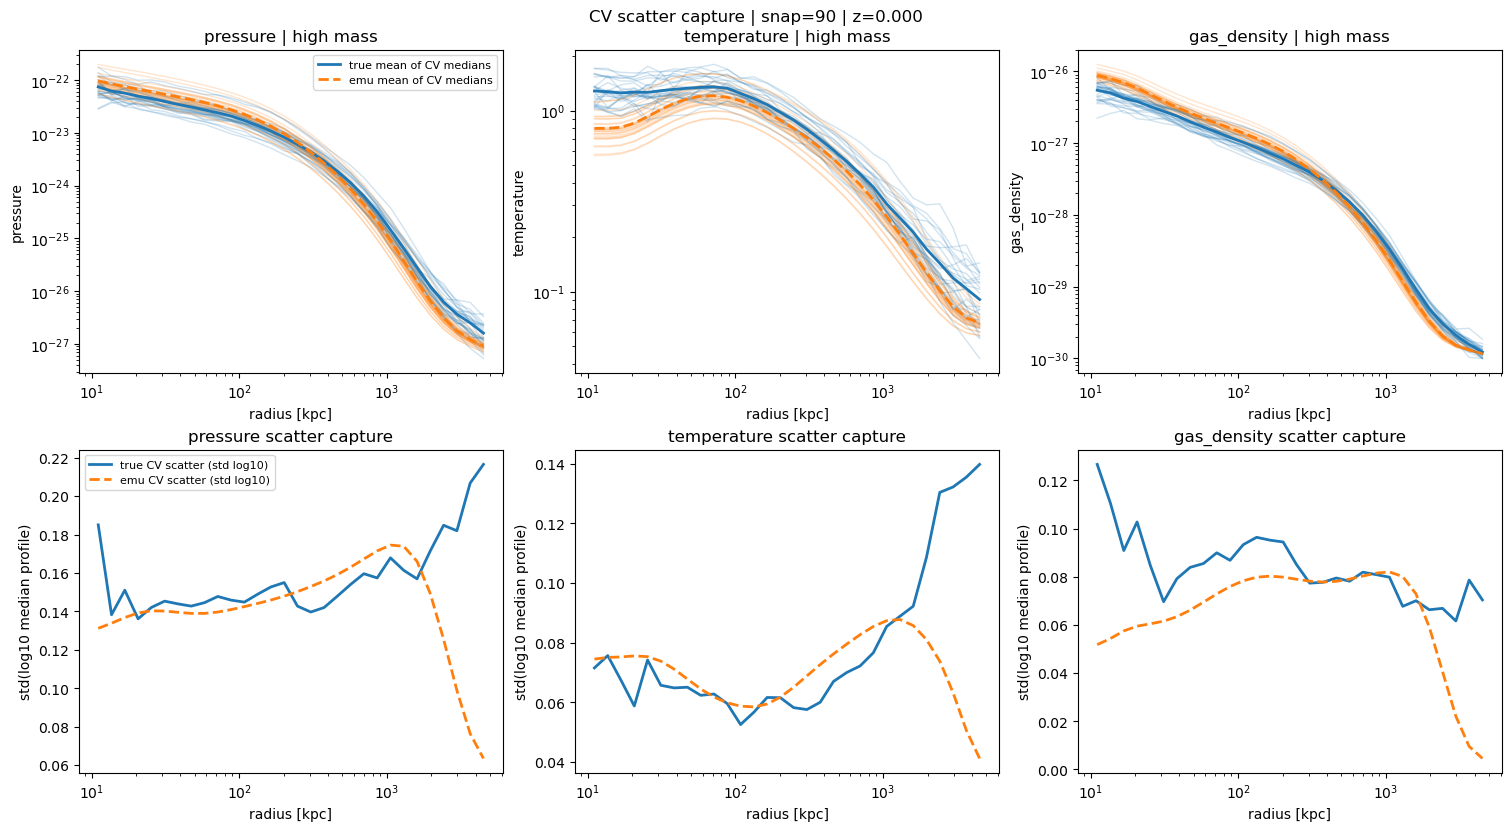

In [29]:
# Visual check: high-mass-only, 3x2 layout (fields as columns), per snapshot.
def _get_cv_predictions_for_snap(snapnum=None):
    if 'cv_predictions_by_snap' not in globals() or len(cv_predictions_by_snap) == 0:
        raise RuntimeError('cv_predictions_by_snap is empty. Run the CV prediction cell first.')

    if snapnum is None:
        snap = int(sorted(cv_predictions_by_snap.keys())[0])
    else:
        snap = int(snapnum)

    if snap not in cv_predictions_by_snap:
        raise KeyError(f'snap {snap} not available. Available: {sorted(cv_predictions_by_snap.keys())}')

    return snap, cv_predictions_by_snap[snap]


def plot_cv_scatter_capture_grid(fields=('pressure', 'temperature', 'gas_density'), mass_bin='high', snapnum=None):
    snap, cvp = _get_cv_predictions_for_snap(snapnum=snapnum)
    tags = sorted(cvp.keys())
    if len(tags) == 0:
        raise RuntimeError(f'No CV predictions found for snap {snap}')

    z = float(training_redshift_by_snap.get(int(snap), np.nan))
    radial_bins = cvp[tags[0]]['radial_bins']
    fig, axes = plt.subplots(2, len(fields), figsize=(5 * len(fields), 8), constrained_layout=True)
    if len(fields) == 1:
        axes = np.array(axes).reshape(2, 1)

    for col, field in enumerate(fields):
        t_medians = []
        p_medians = []

        for tag in tags:
            rec = cvp[tag]
            mass = rec['M500c']
            if mass_bin == 'low':
                mask = mass < CV_MASS_CUT
            elif mass_bin == 'high':
                mask = mass >= CV_MASS_CUT
            else:
                mask = np.ones_like(mass, dtype=bool)

            if np.sum(mask) == 0:
                continue

            true_arr = np.clip(rec['true_profiles'][field][mask], 1e-30, None)
            pred_arr = np.clip(rec['pred_mu'][field][mask], 1e-30, None)

            t_medians.append(np.median(true_arr, axis=0))
            p_medians.append(np.median(pred_arr, axis=0))

        ax_top = axes[0, col]
        ax_bot = axes[1, col]

        if len(t_medians) < 2:
            ax_top.text(0.5, 0.5, 'Need >=2 CV runs', ha='center', va='center', transform=ax_top.transAxes)
            ax_bot.text(0.5, 0.5, 'Need >=2 CV runs', ha='center', va='center', transform=ax_bot.transAxes)
            ax_top.set_title(f'{field} | {mass_bin} mass')
            continue

        t_medians = np.asarray(t_medians)
        p_medians = np.asarray(p_medians)

        t_mean = np.mean(t_medians, axis=0)
        p_mean = np.mean(p_medians, axis=0)
        t_scatter = np.std(np.log10(t_medians), axis=0, ddof=1)
        p_scatter = np.std(np.log10(p_medians), axis=0, ddof=1)

        # Top row: profile overlays + means.
        for i in range(t_medians.shape[0]):
            ax_top.plot(radial_bins, t_medians[i], color='tab:blue', alpha=0.2, lw=1.0)
            ax_top.plot(radial_bins, p_medians[i], color='tab:orange', alpha=0.2, lw=1.0)
        ax_top.plot(radial_bins, t_mean, color='tab:blue', lw=2.0, label='true mean of CV medians')
        ax_top.plot(radial_bins, p_mean, color='tab:orange', lw=2.0, ls='--', label='emu mean of CV medians')
        ax_top.set_xscale('log')
        ax_top.set_yscale('log')
        ax_top.set_xlabel('radius [kpc]')
        ax_top.set_ylabel(field)
        ax_top.set_title(f'{field} | {mass_bin} mass')
        if col == 0:
            ax_top.legend(fontsize=8)

        # Bottom row: scatter capture only (no ratio line).
        ax_bot.plot(radial_bins, t_scatter, color='tab:blue', lw=2.0, label='true CV scatter (std log10)')
        ax_bot.plot(radial_bins, p_scatter, color='tab:orange', lw=2.0, ls='--', label='emu CV scatter (std log10)')
        ax_bot.set_xscale('log')
        ax_bot.set_xlabel('radius [kpc]')
        ax_bot.set_ylabel('std(log10 median profile)')
        ax_bot.set_title(f'{field} scatter capture')
        if col == 0:
            ax_bot.legend(fontsize=8)

    fig.suptitle(f'CV scatter capture | snap={snap} | z={z:.3f}', y=1.02)
    plt.show()


for _snap in cv_snaps_available:
    plot_cv_scatter_capture_grid(fields=('pressure', 'temperature', 'gas_density'), mass_bin='high', snapnum=_snap)

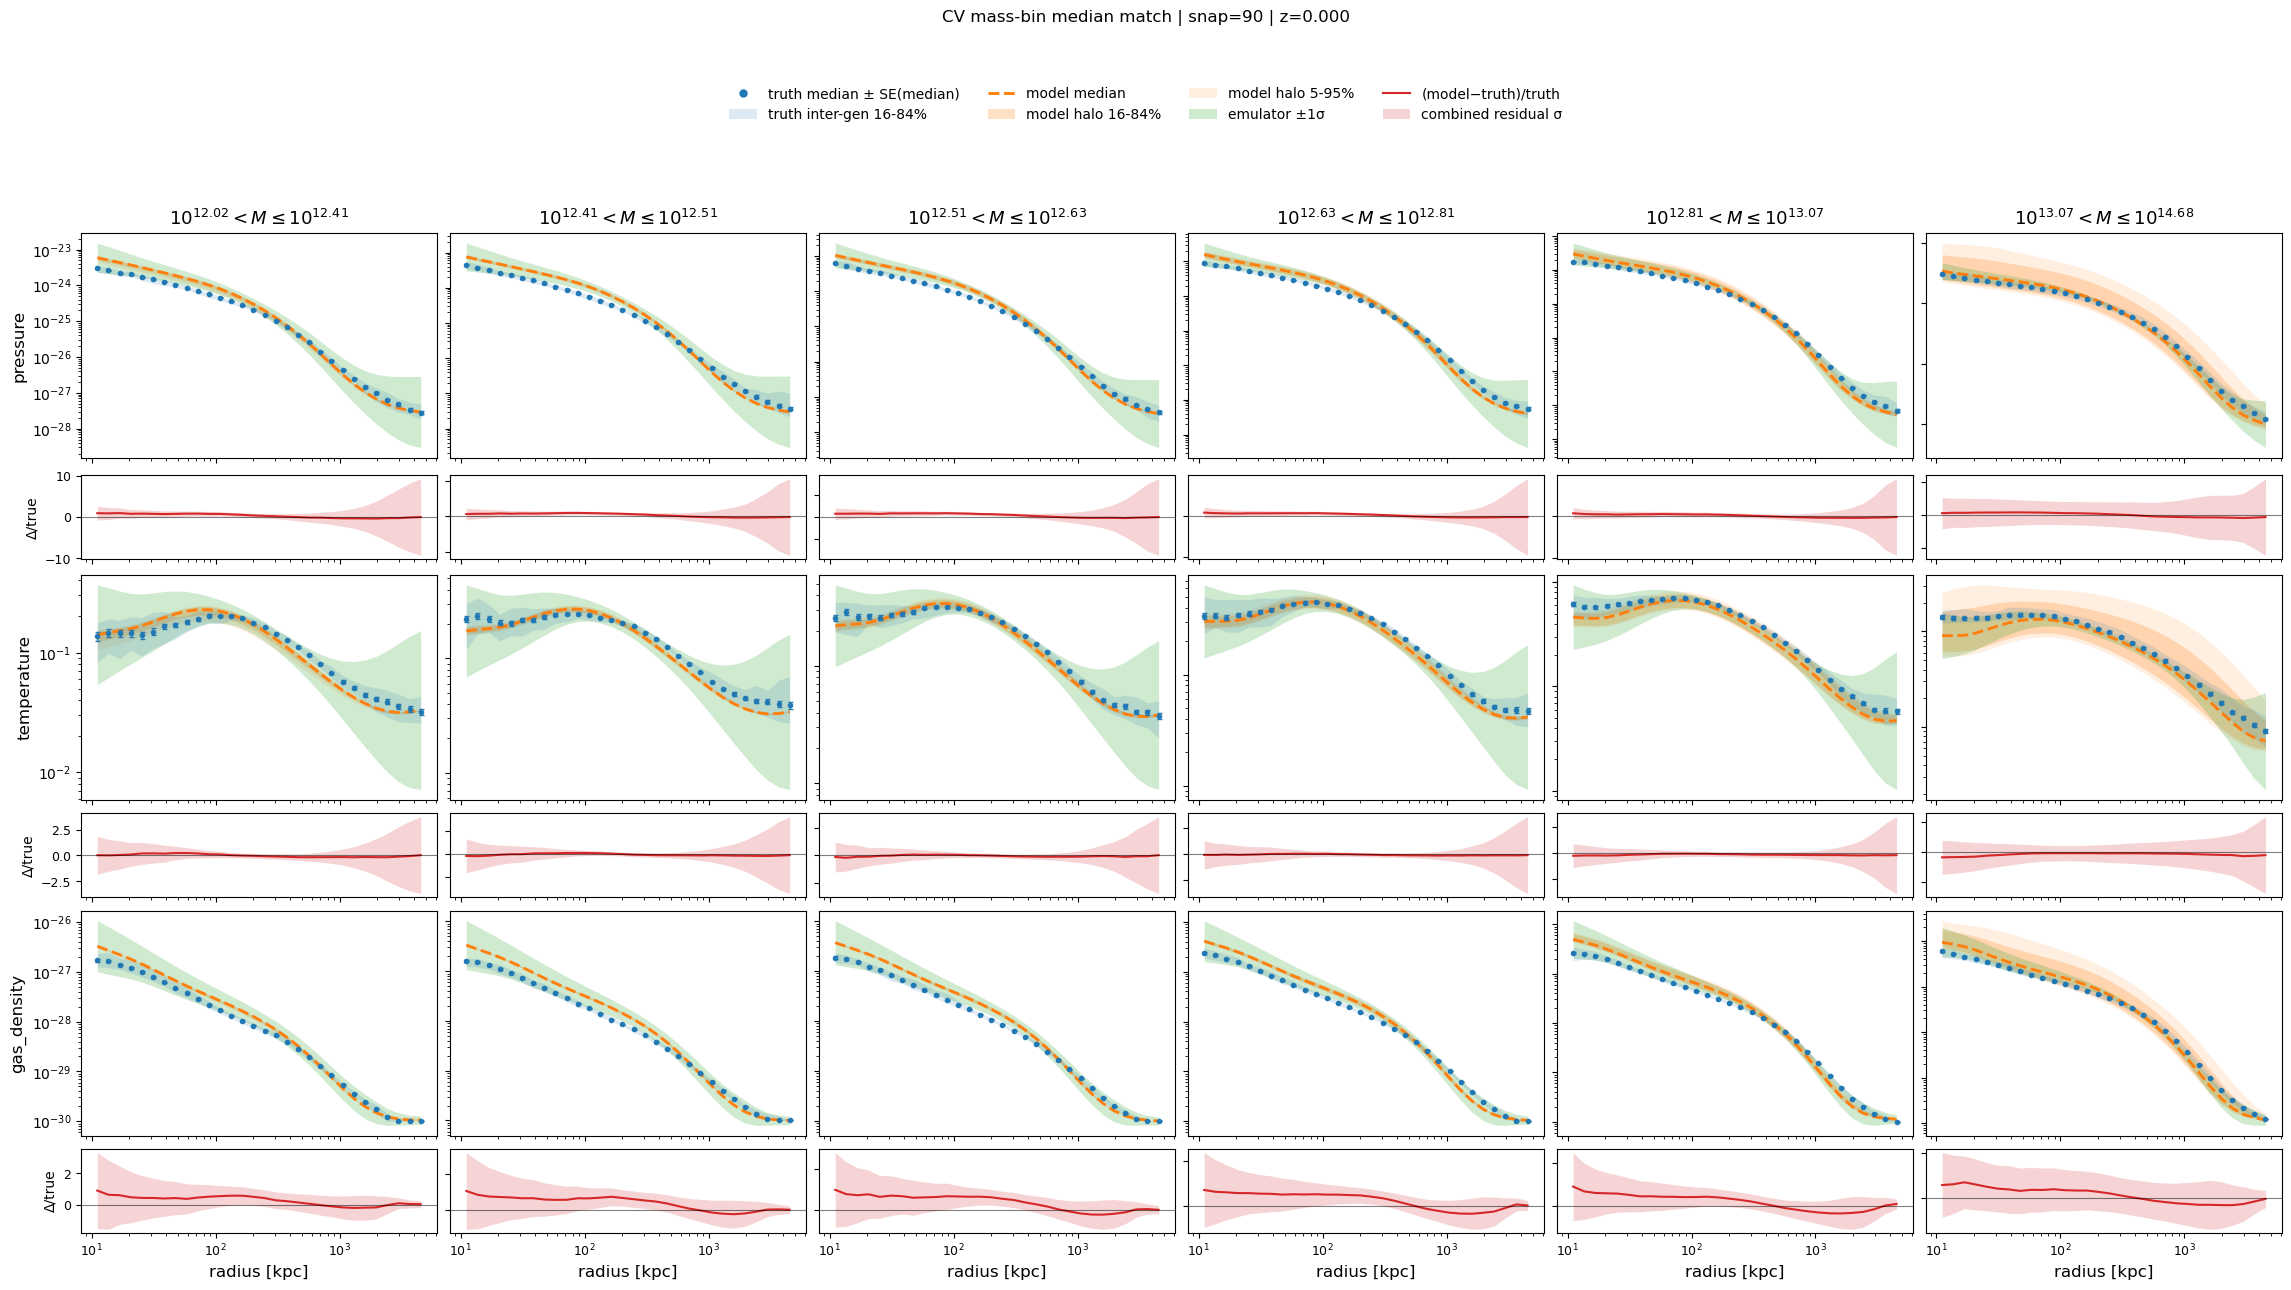

[snap=90] Quantile-based non-linear binning with 6 bins; plotted bins satisfy N >= 20.
Mass-bin median match summary (valid_n marks bins passing the N threshold):


,snapnum,redshift,field,mass_bin,n_halos,valid_n,median_abs_log10_resid,median_abs_rel_diff_pct
0,90,0.0,gas_density,10^12.02-10^12.41,509,True,0.145405,39.772841
1,90,0.0,gas_density,10^12.41-10^12.51,509,True,0.191668,55.477665
2,90,0.0,gas_density,10^12.51-10^12.63,508,True,0.196040,57.071718
3,90,0.0,gas_density,10^12.63-10^12.81,509,True,0.170659,45.902975
4,90,0.0,gas_density,10^12.81-10^13.07,509,True,0.155908,34.534586
5,90,0.0,gas_density,10^13.07-10^14.68,509,True,0.130696,31.766461
6,90,0.0,pressure,10^12.02-10^12.41,509,True,0.167339,37.670508
7,90,0.0,pressure,10^12.41-10^12.51,509,True,0.210895,62.530204
8,90,0.0,pressure,10^12.51-10^12.63,508,True,0.185584,53.391050
9,90,0.0,pressure,10^12.63-10^12.81,509,True,0.195691,39.256943


Combined summary across all CV snapshots:


,snapnum,field,n_bins,n_valid_bins,med_abs_log10_resid,med_abs_rel_diff_pct
0,90,gas_density,6,6,0.163283,42.837908
1,90,pressure,6,6,0.176461,39.343066
2,90,temperature,6,6,0.060417,12.986787


In [30]:
# CV mass-bin median-profile validation across all halos, per snapshot.
def plot_cv_massbin_median_match(
    fields=('pressure', 'temperature', 'gas_density'),
    logm_start=12.0,
    n_mass_bins=6,
    min_count_per_bin=20,
    eps=1e-30,
    snapnum=None,
):
    snap, cvp = _get_cv_predictions_for_snap(snapnum=snapnum)
    tags = sorted(cvp.keys())
    if len(tags) == 0:
        raise RuntimeError(f'No CV predictions found for snap {snap}')

    # Gather all halo masses and build non-linear bins via quantiles.
    all_logm = []
    for tag in tags:
        m = np.asarray(cvp[tag]['M500c'], dtype=np.float64)
        all_logm.append(np.log10(np.clip(m, 1e-30, None)))
    all_logm = np.concatenate(all_logm)

    pool = all_logm[all_logm >= float(logm_start)]
    if pool.size < max(2, n_mass_bins):
        pool = all_logm.copy()

    q = np.linspace(0.0, 1.0, int(n_mass_bins) + 1)
    edges = np.quantile(pool, q)
    edges = np.unique(edges)

    # Fallback to linear spacing if quantiles collapse due to repeated values.
    if edges.size < int(n_mass_bins) + 1:
        lo = max(float(logm_start), float(np.nanmin(all_logm)))
        hi = float(np.nanmax(all_logm))
        if hi <= lo:
            hi = lo + 0.2
        edges = np.linspace(lo, hi, int(n_mass_bins) + 1)

    n_bins = len(edges) - 1
    labels = []
    for i in range(n_bins):
        labels.append(f'10^{edges[i]:.2f}-10^{edges[i+1]:.2f}')

    # Radial-grid consistency check across CV runs.
    radial_ref = np.asarray(cvp[tags[0]]['radial_bins'], dtype=np.float64)
    for tag in tags[1:]:
        rb = np.asarray(cvp[tag]['radial_bins'], dtype=np.float64)
        if rb.shape != radial_ref.shape or not np.allclose(rb, radial_ref, rtol=1e-6, atol=1e-12):
            raise ValueError(f'Radial bins mismatch for tag {tag}; expected common grid for bin medians.')

    # Total halo count per bin (shared across fields).
    bin_counts = {}
    for i_bin, label in enumerate(labels):
        lo, hi = edges[i_bin], edges[i_bin + 1]
        if i_bin < len(labels) - 1:
            sel = (all_logm >= lo) & (all_logm < hi)
        else:
            sel = (all_logm >= lo) & (all_logm <= hi)
        bin_counts[label] = int(np.sum(sel))

    medians = {fld: {} for fld in fields}
    summary_rows = []

    for i_bin, bin_label in enumerate(labels):
        lo, hi = edges[i_bin], edges[i_bin + 1]

        for fld in fields:
            true_stack = []
            pred_stack = []
            pred_sd_log_stack = []
            tag_true_meds = []
            tag_pred_meds = []

            for tag in tags:
                rec = cvp[tag]
                mass = np.asarray(rec['M500c'], dtype=np.float64)
                logm = np.log10(np.clip(mass, 1e-30, None))

                if i_bin < len(labels) - 1:
                    mask = (logm >= lo) & (logm < hi)
                else:
                    mask = (logm >= lo) & (logm <= hi)

                if not np.any(mask):
                    continue

                true_arr = np.asarray(rec['true_profiles'][fld], dtype=np.float64)[mask]
                pred_arr = np.asarray(rec['pred_mu'][fld], dtype=np.float64)[mask]
                sd_log_arr = np.asarray(rec['pred_sd_log'][fld], dtype=np.float64)[mask]
                true_stack.append(true_arr)
                pred_stack.append(pred_arr)
                pred_sd_log_stack.append(sd_log_arr)
                tag_true_meds.append(np.median(np.clip(true_arr, eps, None), axis=0))
                tag_pred_meds.append(np.median(np.clip(pred_arr, eps, None), axis=0))

            n_halos = int(bin_counts[bin_label])
            is_valid = n_halos >= int(min_count_per_bin)

            if len(true_stack) == 0:
                medians[fld][bin_label] = None
                summary_rows.append({
                    'snapnum': int(snap),
                    'redshift': float(training_redshift_by_snap.get(int(snap), np.nan)),
                    'field': fld,
                    'mass_bin': bin_label,
                    'n_halos': n_halos,
                    'valid_n': bool(is_valid),
                    'median_abs_log10_resid': np.nan,
                    'median_abs_rel_diff_pct': np.nan,
                })
                continue

            true_stack = np.vstack(true_stack)
            pred_stack = np.vstack(pred_stack)
            pred_sd_log_all = np.vstack(pred_sd_log_stack)

            true_clip = np.clip(true_stack, eps, None)
            pred_clip = np.clip(pred_stack, eps, None)

            true_med = np.median(true_clip, axis=0)
            pred_med = np.median(pred_clip, axis=0)

            # SE of median computed in log10 space so error bars are
            # symmetric on the log-scale axes.
            log_true = np.log10(true_clip)
            log_true_med = np.median(log_true, axis=0)
            mad_log = np.median(np.abs(log_true - log_true_med[None, :]), axis=0)
            sigma_log_rob = 1.4826 * mad_log
            true_med_se_log = 1.2533 * sigma_log_rob / np.sqrt(max(n_halos, 1))

            # Model contour bands from halo-to-halo spread in emulator medians.
            pred_q16 = np.quantile(pred_clip, 0.16, axis=0)
            pred_q84 = np.quantile(pred_clip, 0.84, axis=0)
            pred_q05 = np.quantile(pred_clip, 0.05, axis=0)
            pred_q95 = np.quantile(pred_clip, 0.95, axis=0)

            # Emulator self-reported uncertainty in log10 space (median across halos).
            pred_sd_log_med = np.median(pred_sd_log_all, axis=0)

            # Inter-generation scatter: spread of per-tag median profiles.
            tag_true_meds_arr = np.asarray(tag_true_meds)
            tag_pred_meds_arr = np.asarray(tag_pred_meds)
            n_tags = tag_true_meds_arr.shape[0]
            if n_tags >= 2:
                gen_true_lo = np.quantile(tag_true_meds_arr, 0.16, axis=0)
                gen_true_hi = np.quantile(tag_true_meds_arr, 0.84, axis=0)
                gen_pred_lo = np.quantile(tag_pred_meds_arr, 0.16, axis=0)
                gen_pred_hi = np.quantile(tag_pred_meds_arr, 0.84, axis=0)
            else:
                gen_true_lo = gen_true_hi = true_med
                gen_pred_lo = gen_pred_hi = pred_med

            log_resid = np.log10(np.clip(pred_med, eps, None)) - np.log10(np.clip(true_med, eps, None))
            rel_diff = (pred_med - true_med) / np.clip(true_med, eps, None)

            medians[fld][bin_label] = {
                'true_med': true_med,
                'true_med_se_log': np.clip(true_med_se_log, 0.0, None),
                'pred_med': pred_med,
                'pred_q16': pred_q16,
                'pred_q84': pred_q84,
                'pred_q05': pred_q05,
                'pred_q95': pred_q95,
                'pred_sd_log_med': pred_sd_log_med,
                'gen_true_lo': gen_true_lo,
                'gen_true_hi': gen_true_hi,
                'gen_pred_lo': gen_pred_lo,
                'gen_pred_hi': gen_pred_hi,
                'n_tags': n_tags,
                'n_halos': n_halos,
                'valid_n': bool(is_valid),
                'median_abs_log10_resid': float(np.median(np.abs(log_resid))),
                'median_abs_rel_diff_pct': float(100.0 * np.median(np.abs(rel_diff))),
            }

            summary_rows.append({
                'snapnum': int(snap),
                'redshift': float(training_redshift_by_snap.get(int(snap), np.nan)),
                'field': fld,
                'mass_bin': bin_label,
                'n_halos': n_halos,
                'valid_n': bool(is_valid),
                'median_abs_log10_resid': float(np.median(np.abs(log_resid))),
                'median_abs_rel_diff_pct': float(100.0 * np.median(np.abs(rel_diff))),
            })

    summary_df = pd.DataFrame(summary_rows)
    valid_labels = [lab for lab in labels if bin_counts[lab] >= int(min_count_per_bin)]

    if len(valid_labels) == 0:
        print(f'[snap={snap}] No bins satisfy N >= {min_count_per_bin}.')
        print('Mass-bin summary (including underpopulated bins):')
        display(summary_df.sort_values(['field', 'mass_bin']).reset_index(drop=True))
        return summary_df, medians, edges

    # Styling knobs for presentation readability.
    title_fs = 13
    label_fs = 12
    tick_fs = 10

    # For each field, make a main row + a shorter residual row.
    n_fields = len(fields)
    n_cols = len(valid_labels)
    n_rows_total = 2 * n_fields
    height_ratios = []
    for _ in range(n_fields):
        height_ratios.extend([3.2, 1.2])

    fig, axes = plt.subplots(
        n_rows_total,
        n_cols,
        figsize=(3.8 * n_cols, 3.6 * n_fields),
        constrained_layout=True,
        sharex='col',
        gridspec_kw={'height_ratios': height_ratios},
    )

    if n_rows_total == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows_total == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = np.array(axes).reshape(n_rows_total, 1)

    for j_col, bin_label in enumerate(valid_labels):
        lo = edges[labels.index(bin_label)]
        hi = edges[labels.index(bin_label) + 1]

        # Only top row gets mass-range title in LaTeX.
        axes[0, j_col].set_title(rf'$10^{{{lo:.2f}}} < M \leq 10^{{{hi:.2f}}}$', fontsize=title_fs)

        for i_fld, fld in enumerate(fields):
            ax_main = axes[2 * i_fld, j_col]
            ax_res = axes[2 * i_fld + 1, j_col]
            rec = medians[fld][bin_label]

            if rec is None:
                ax_main.text(0.5, 0.5, 'No halos', ha='center', va='center', transform=ax_main.transAxes)
                ax_main.set_xscale('log')
                ax_main.set_yscale('log')
                ax_res.set_xscale('log')
                ax_res.axhline(0.0, color='k', lw=0.8, alpha=0.4)
                continue

            true_med = rec['true_med']
            true_med_se_log = rec['true_med_se_log']
            pred_med = rec['pred_med']
            pred_q16 = np.clip(rec['pred_q16'], eps, None)
            pred_q84 = np.clip(rec['pred_q84'], eps, None)
            pred_q05 = np.clip(rec['pred_q05'], eps, None)
            pred_q95 = np.clip(rec['pred_q95'], eps, None)
            pred_sd_log_med = rec['pred_sd_log_med']
            gen_true_lo = np.clip(rec['gen_true_lo'], eps, None)
            gen_true_hi = np.clip(rec['gen_true_hi'], eps, None)

            # Model contours (halo-to-halo spread of emulator point predictions).
            ax_main.fill_between(radial_ref, pred_q05, pred_q95, color='tab:orange', alpha=0.12, linewidth=0)
            ax_main.fill_between(radial_ref, pred_q16, pred_q84, color='tab:orange', alpha=0.24, linewidth=0)

            # Emulator self-reported uncertainty band (native log-space σ).
            log_pred_med = np.log10(np.clip(pred_med, eps, None))
            ax_main.fill_between(
                radial_ref,
                10.0 ** (log_pred_med - pred_sd_log_med),
                10.0 ** (log_pred_med + pred_sd_log_med),
                color='tab:green', alpha=0.22, linewidth=0,
            )

            ax_main.plot(radial_ref, pred_med, color='tab:orange', lw=2.1, ls='--')

            # Inter-generation truth scatter band (16-84% of per-tag medians).
            ax_main.fill_between(radial_ref, gen_true_lo, gen_true_hi, color='tab:blue', alpha=0.15, linewidth=0)

            # Truth points with symmetric log-space error bars.
            log_true_med = np.log10(np.clip(true_med, eps, None))
            step = max(1, radial_ref.size // 16)
            idx = np.arange(0, radial_ref.size, step)
            err_lo = np.clip(true_med[idx] - 10.0 ** (log_true_med[idx] - true_med_se_log[idx]), 0.0, None)
            err_hi = np.clip(10.0 ** (log_true_med[idx] + true_med_se_log[idx]) - true_med[idx], 0.0, None)
            ax_main.errorbar(
                radial_ref[idx],
                true_med[idx],
                yerr=[err_lo, err_hi],
                fmt='o',
                ms=3.0,
                lw=0.9,
                elinewidth=0.9,
                capsize=1.8,
                color='tab:blue',
                alpha=0.95,
            )

            # Residual panel: relative difference with all error sources propagated.
            # Work in log10 space so all σ terms combine symmetrically.
            sigma_model_log = 0.5 * (np.log10(np.clip(pred_q84, eps, None))
                                     - np.log10(np.clip(pred_q16, eps, None)))
            sigma_emu_log = pred_sd_log_med
            sigma_gen_log = 0.5 * (np.log10(np.clip(rec['gen_true_hi'], eps, None))
                                   - np.log10(np.clip(rec['gen_true_lo'], eps, None)))
            denom = np.clip(true_med, eps, None)
            rel = (pred_med - true_med) / denom
            # Convert combined log10 σ back to fractional σ: 10^σ_log − 1
            combined_log_sigma = np.sqrt(
                sigma_model_log ** 2
                + sigma_emu_log ** 2
                + sigma_gen_log ** 2
                + true_med_se_log ** 2
            )
            rel_sigma = 10.0 ** combined_log_sigma - 1.0

            ax_res.plot(radial_ref, rel, color='tab:red', lw=1.5)
            ax_res.fill_between(radial_ref, rel - rel_sigma, rel + rel_sigma, color='tab:red', alpha=0.2, linewidth=0)
            ax_res.axhline(0.0, color='k', lw=0.8, alpha=0.5)

            ax_main.set_xscale('log')
            ax_main.set_yscale('log')
            ax_res.set_xscale('log')
            ax_main.tick_params(axis='both', which='both', labelsize=tick_fs)
            ax_res.tick_params(axis='both', which='both', labelsize=max(8, tick_fs - 1))

            # Y-axis formatting and clutter control.
            if j_col == 0:
                ax_main.set_ylabel(fld, fontsize=label_fs)
                ax_res.set_ylabel('Δ/true', fontsize=max(9, label_fs - 2))
                ax_main.tick_params(labelleft=True)
                ax_res.tick_params(labelleft=True)
            else:
                ax_main.set_ylabel('')
                ax_res.set_ylabel('')
                ax_main.tick_params(labelleft=False)
                ax_res.tick_params(labelleft=False)

            # Only bottom residual row gets x-label.
            if i_fld == n_fields - 1:
                ax_res.set_xlabel('radius [kpc]', fontsize=label_fs)

    # One clean legend outside the plotting area (above the figure).
    legend_handles = [
        plt.Line2D([0], [0], color='tab:blue', marker='o', linestyle='None', markersize=5, label='truth median ± SE(median)'),
        plt.Rectangle((0, 0), 1, 1, fc='tab:blue', alpha=0.15, label='truth inter-gen 16-84%'),
        plt.Line2D([0], [0], color='tab:orange', lw=2.1, ls='--', label='model median'),
        plt.Rectangle((0, 0), 1, 1, fc='tab:orange', alpha=0.24, label='model halo 16-84%'),
        plt.Rectangle((0, 0), 1, 1, fc='tab:orange', alpha=0.12, label='model halo 5-95%'),
        plt.Rectangle((0, 0), 1, 1, fc='tab:green', alpha=0.22, label='emulator ±1σ'),
        plt.Line2D([0], [0], color='tab:red', lw=1.5, label='(model−truth)/truth'),
        plt.Rectangle((0, 0), 1, 1, fc='tab:red', alpha=0.2, label='combined residual σ'),
    ]
    z = float(training_redshift_by_snap.get(int(snap), np.nan))
    fig.legend(
        handles=legend_handles,
        loc='upper center',
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 1.12),
        fontsize=10,
    )
    fig.suptitle(f'CV mass-bin median match | snap={snap} | z={z:.3f}', y=1.18)

    plt.show()

    print(
        f'[snap={snap}] Quantile-based non-linear binning with {n_mass_bins} bins; '
        f'plotted bins satisfy N >= {min_count_per_bin}.'
    )
    print('Mass-bin median match summary (valid_n marks bins passing the N threshold):')
    display(summary_df.sort_values(['field', 'mass_bin']).reset_index(drop=True))

    return summary_df, medians, edges


cv_massbin_summary_by_snap = {}
cv_massbin_medians_by_snap = {}
cv_massbin_edges_by_snap = {}
_all_cv_massbin_frames = []

for _snap in cv_snaps_available:
    summary_df_i, medians_i, edges_i = plot_cv_massbin_median_match(
        fields=('pressure', 'temperature', 'gas_density'),
        logm_start=12.0,
        n_mass_bins=6,
        min_count_per_bin=20,
        snapnum=_snap,
    )
    cv_massbin_summary_by_snap[int(_snap)] = summary_df_i
    cv_massbin_medians_by_snap[int(_snap)] = medians_i
    cv_massbin_edges_by_snap[int(_snap)] = edges_i
    _all_cv_massbin_frames.append(summary_df_i)

cv_massbin_summary_df_all = pd.concat(_all_cv_massbin_frames, ignore_index=True)

# Backward-compatible aliases for existing downstream references.
cv_massbin_summary_df = cv_massbin_summary_by_snap[first_snap]
cv_massbin_medians = cv_massbin_medians_by_snap[first_snap]
cv_massbin_edges = cv_massbin_edges_by_snap[first_snap]

print('Combined summary across all CV snapshots:')
display(
    cv_massbin_summary_df_all.groupby(['snapnum', 'field'], as_index=False)
    .agg(
        n_bins=('mass_bin', 'count'),
        n_valid_bins=('valid_n', 'sum'),
        med_abs_log10_resid=('median_abs_log10_resid', 'median'),
        med_abs_rel_diff_pct=('median_abs_rel_diff_pct', 'median'),
    )
    .sort_values(['snapnum', 'field'])
    .reset_index(drop=True)
)

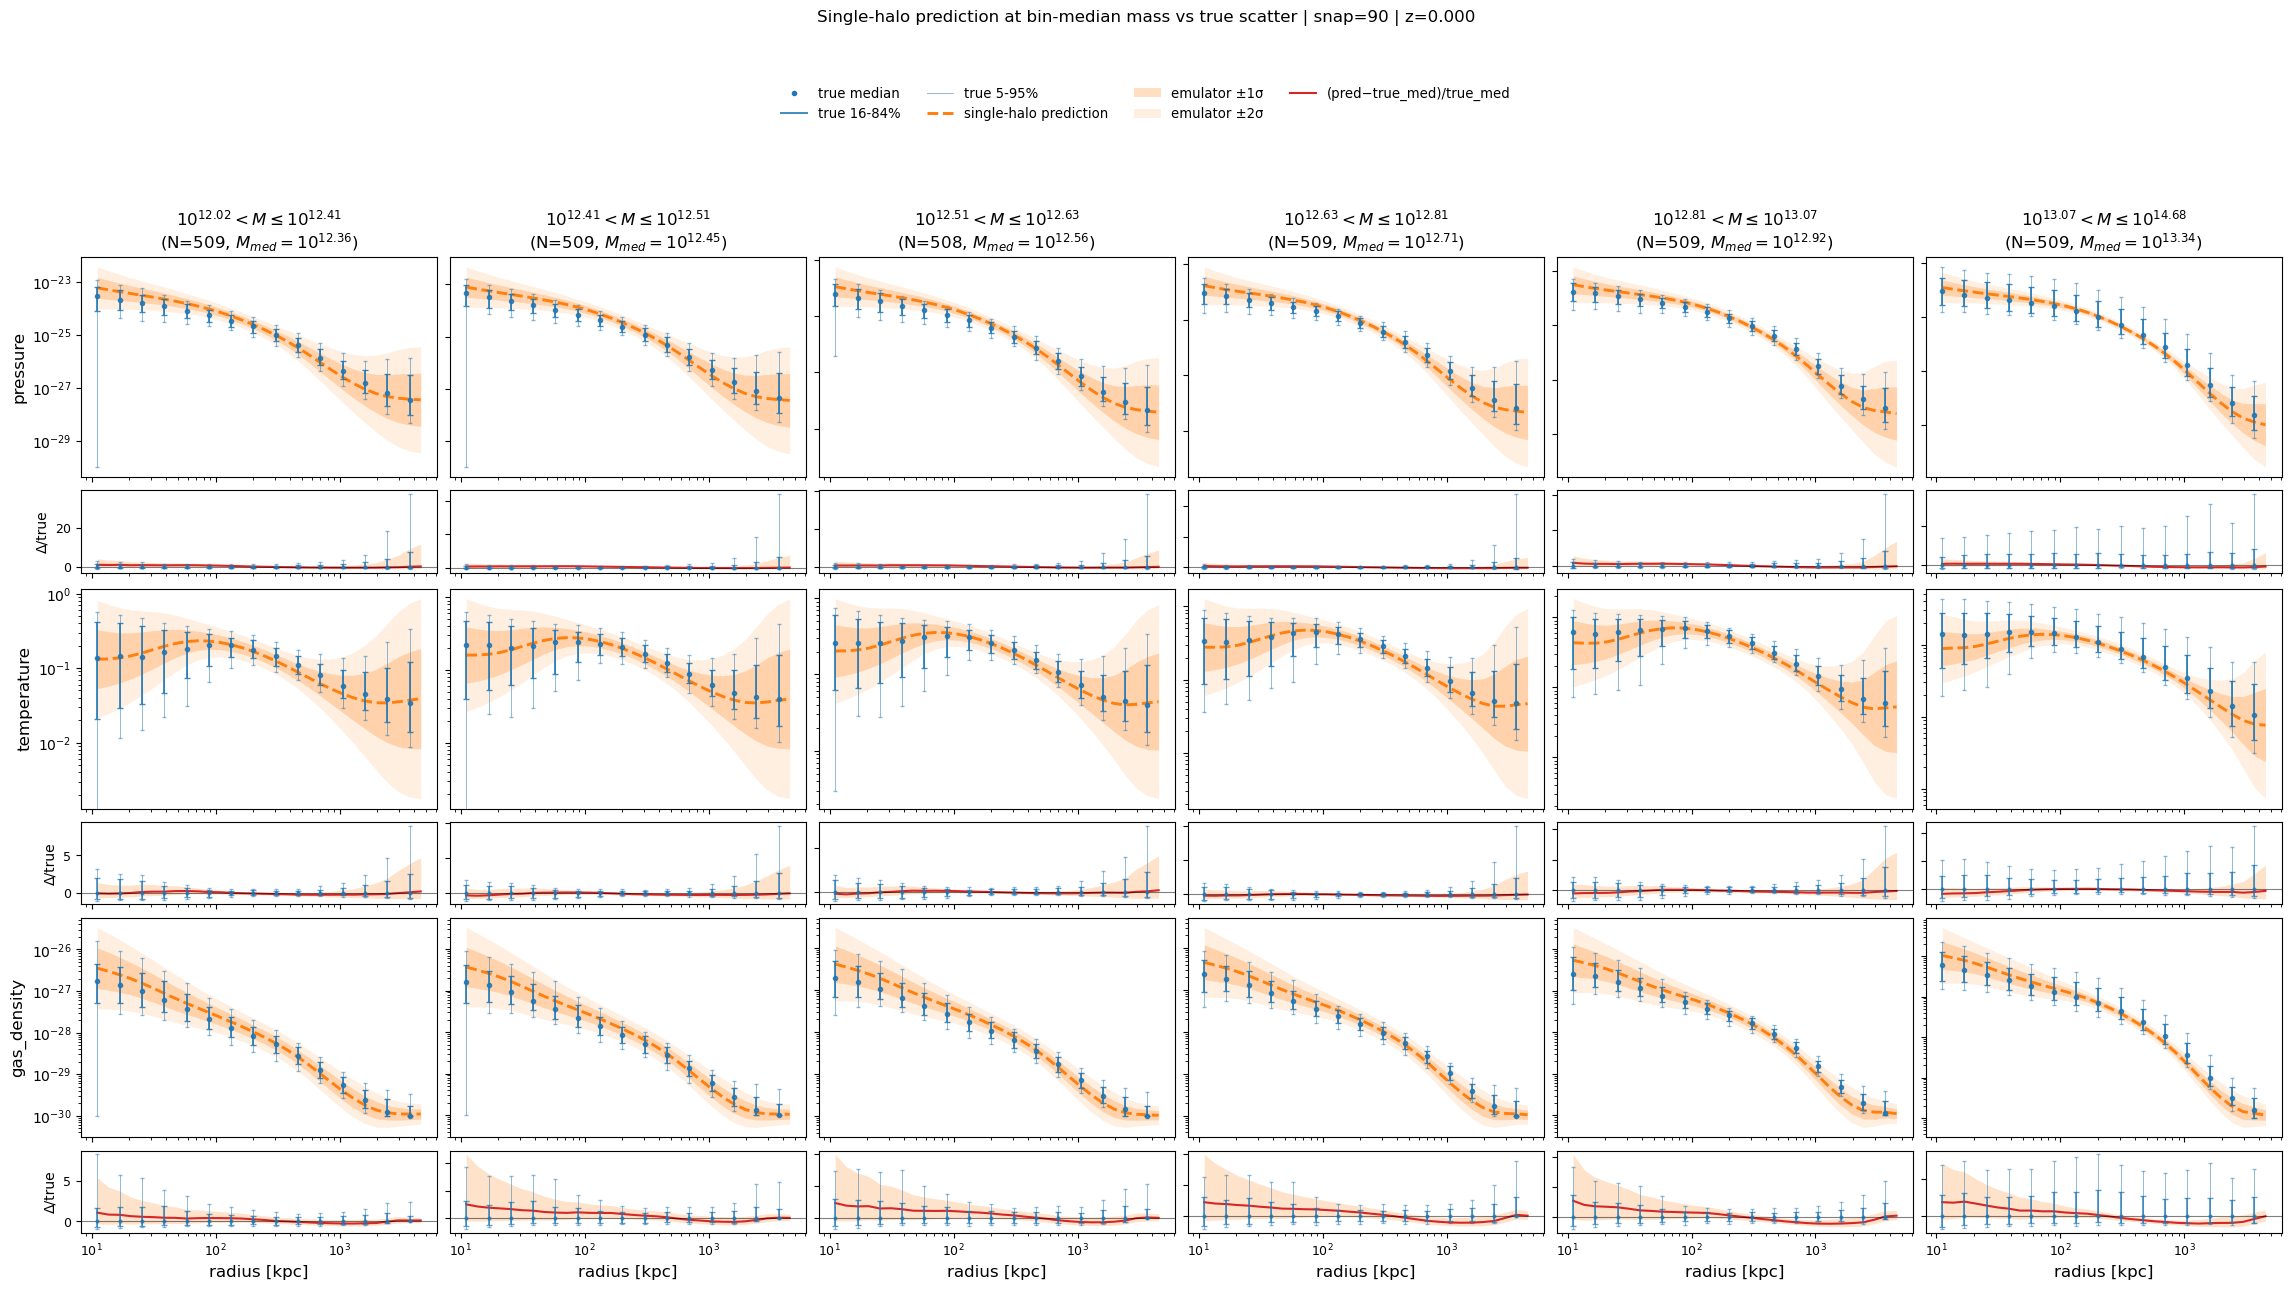

In [9]:
# Single-halo prediction at bin-median mass vs true halo scatter.
# For each mass bin, predict ONE halo at the median mass & median R500c,
# then compare the emulator prediction ± uncertainty against the true halos.

def plot_single_median_halo_vs_scatter(
    fields=('pressure', 'temperature', 'gas_density'),
    logm_start=12.0,
    n_mass_bins=6,
    min_count_per_bin=20,
    eps=1e-30,
    snapnum=None,
):
    snap, cvp = _get_cv_predictions_for_snap(snapnum=snapnum)
    tags = sorted(cvp.keys())
    if len(tags) == 0:
        raise RuntimeError(f'No CV predictions found for snap {snap}')

    z_snap = float(training_redshift_by_snap.get(int(snap), np.nan))
    radial_ref = np.asarray(cvp[tags[0]]['radial_bins'], dtype=np.float64)

    # ---- Build mass bins (same logic as the median-match plot) ----
    all_logm = []
    all_masses = []
    all_r500c = []
    all_true = {fld: [] for fld in fields}
    for tag in tags:
        rec = cvp[tag]
        mass = np.asarray(rec['M500c'], dtype=np.float64)
        r500 = np.asarray(rec['R500c'], dtype=np.float64)
        all_masses.append(mass)
        all_r500c.append(r500)
        all_logm.append(np.log10(np.clip(mass, 1e-30, None)))
        for fld in fields:
            all_true[fld].append(np.asarray(rec['true_profiles'][fld], dtype=np.float64))

    all_logm = np.concatenate(all_logm)
    all_masses = np.concatenate(all_masses)
    all_r500c = np.concatenate(all_r500c)
    for fld in fields:
        all_true[fld] = np.vstack(all_true[fld])

    pool = all_logm[all_logm >= float(logm_start)]
    if pool.size < max(2, n_mass_bins):
        pool = all_logm.copy()

    q = np.linspace(0.0, 1.0, int(n_mass_bins) + 1)
    edges = np.unique(np.quantile(pool, q))
    if edges.size < int(n_mass_bins) + 1:
        lo_e = max(float(logm_start), float(np.nanmin(all_logm)))
        hi_e = float(np.nanmax(all_logm))
        if hi_e <= lo_e:
            hi_e = lo_e + 0.2
        edges = np.linspace(lo_e, hi_e, int(n_mass_bins) + 1)

    n_bins = len(edges) - 1
    labels = [f'10^{edges[i]:.2f}-10^{edges[i+1]:.2f}' for i in range(n_bins)]

    # ---- Identify valid bins and bin properties ----
    bin_info = []
    for i_bin, label in enumerate(labels):
        lo_e, hi_e = edges[i_bin], edges[i_bin + 1]
        if i_bin < n_bins - 1:
            sel = (all_logm >= lo_e) & (all_logm < hi_e)
        else:
            sel = (all_logm >= lo_e) & (all_logm <= hi_e)

        n_in_bin = int(np.sum(sel))
        if n_in_bin < int(min_count_per_bin):
            continue

        med_mass = float(np.median(all_masses[sel]))
        med_r500 = float(np.median(all_r500c[sel]))
        true_in_bin = {fld: all_true[fld][sel] for fld in fields}

        bin_info.append({
            'label': label,
            'lo': lo_e, 'hi': hi_e,
            'n_halos': n_in_bin,
            'med_mass': med_mass,
            'med_r500': med_r500,
            'true_in_bin': true_in_bin,
        })

    if len(bin_info) == 0:
        print(f'[snap={snap}] No bins satisfy N >= {min_count_per_bin}.')
        return

    # ---- Run emulator for one halo per bin ----
    single_masses = np.array([b['med_mass'] for b in bin_info], dtype=np.float32)
    single_r500 = np.array([b['med_r500'] for b in bin_info], dtype=np.float64)
    single_rr500 = (radial_ref[None, :] / np.maximum(single_r500[:, None], 1e-12)).astype(np.float32)

    pred = emu.predict(
        theta=theta_fid,
        M=single_masses,
        r_bins=single_rr500,
        field=list(fields),
        snapnum=int(snap),
        redshift=z_snap,
        n_samples=CV_NSAMPLES,
    )

    # ---- Plotting ----
    title_fs = 13
    label_fs = 12
    tick_fs = 10

    n_fields = len(fields)
    n_cols = len(bin_info)
    n_rows_total = 2 * n_fields
    height_ratios = []
    for _ in range(n_fields):
        height_ratios.extend([3.2, 1.2])

    fig, axes = plt.subplots(
        n_rows_total, n_cols,
        figsize=(3.8 * n_cols, 3.6 * n_fields),
        constrained_layout=True,
        sharex='col',
        gridspec_kw={'height_ratios': height_ratios},
    )
    if n_rows_total == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows_total == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = np.array(axes).reshape(n_rows_total, 1)

    # Subsample radial grid for errorbars (avoid overcrowding on log axis).
    step = max(1, radial_ref.size // 14)
    idx = np.arange(0, radial_ref.size, step)

    for j_col, binfo in enumerate(bin_info):
        lo_e, hi_e = binfo['lo'], binfo['hi']
        axes[0, j_col].set_title(
            rf'$10^{{{lo_e:.2f}}} < M \leq 10^{{{hi_e:.2f}}}$'
            f'\n(N={binfo["n_halos"]}, '
            rf'$M_{{med}}=10^{{{np.log10(binfo["med_mass"]):.2f}}}$)',
            fontsize=title_fs - 1,
        )

        for i_fld, fld in enumerate(fields):
            ax_main = axes[2 * i_fld, j_col]
            ax_res = axes[2 * i_fld + 1, j_col]

            # True halo profiles in this bin.
            true_bin = np.clip(binfo['true_in_bin'][fld], eps, None)
            true_med = np.median(true_bin, axis=0)
            true_q16 = np.quantile(true_bin, 0.16, axis=0)
            true_q84 = np.quantile(true_bin, 0.84, axis=0)
            true_q05 = np.quantile(true_bin, 0.05, axis=0)
            true_q95 = np.quantile(true_bin, 0.95, axis=0)

            # Single-halo emulator prediction.
            fld_idx = list(pred.field_names).index(fld)
            pred_mu = np.asarray(pred.mean[j_col, :, fld_idx], dtype=np.float64)
            pred_std = np.asarray(pred.total_std[j_col, :, fld_idx], dtype=np.float64)

            # Uncertainty bands in physical space from log10 std.
            if pred.std_log10 is not None:
                sd_log = np.asarray(pred.std_log10[j_col, :, fld_idx], dtype=np.float64)
            else:
                sd_log = np.log10(np.e) * pred_std / np.clip(pred_mu, eps, None)

            log_pred = np.log10(np.clip(pred_mu, eps, None))
            pred_lo1 = 10.0 ** (log_pred - sd_log)
            pred_hi1 = 10.0 ** (log_pred + sd_log)
            pred_lo2 = 10.0 ** (log_pred - 2 * sd_log)
            pred_hi2 = 10.0 ** (log_pred + 2 * sd_log)

            # --- Main panel ---
            # True halos: errorbar points (outer = 5-95% thin, inner = 16-84% thick).
            err_outer = np.array([
                true_med[idx] - true_q05[idx],
                true_q95[idx] - true_med[idx],
            ])
            err_inner = np.array([
                true_med[idx] - true_q16[idx],
                true_q84[idx] - true_med[idx],
            ])
            ax_main.errorbar(
                radial_ref[idx], true_med[idx], yerr=err_outer,
                fmt='none', ecolor='tab:blue', elinewidth=0.7,
                capsize=1.5, alpha=0.5, zorder=2,
            )
            ax_main.errorbar(
                radial_ref[idx], true_med[idx], yerr=err_inner,
                fmt='o', ms=3.0, color='tab:blue', ecolor='tab:blue',
                elinewidth=1.4, capsize=2.2, alpha=0.85, zorder=3,
                label='true median',
            )

            # Single prediction ± uncertainty.
            ax_main.fill_between(radial_ref, pred_lo2, pred_hi2,
                                 color='tab:orange', alpha=0.12, linewidth=0)
            ax_main.fill_between(radial_ref, pred_lo1, pred_hi1,
                                 color='tab:orange', alpha=0.25, linewidth=0)
            ax_main.plot(radial_ref, pred_mu, color='tab:orange', lw=2.1, ls='--',
                         label='prediction (median M)')

            ax_main.set_xscale('log')
            ax_main.set_yscale('log')
            ax_main.tick_params(axis='both', which='both', labelsize=tick_fs)

            # --- Residual panel ---
            denom = np.clip(true_med, eps, None)
            rel = (pred_mu - true_med) / denom

            # True scatter as fractional errorbars centred on zero.
            frac_outer = np.array([
                (true_med[idx] - true_q05[idx]) / denom[idx],
                (true_q95[idx] - true_med[idx]) / denom[idx],
            ])
            frac_inner = np.array([
                (true_med[idx] - true_q16[idx]) / denom[idx],
                (true_q84[idx] - true_med[idx]) / denom[idx],
            ])
            ax_res.errorbar(
                radial_ref[idx], np.zeros(len(idx)), yerr=frac_outer,
                fmt='none', ecolor='tab:blue', elinewidth=0.7,
                capsize=1.5, alpha=0.5, zorder=2,
            )
            ax_res.errorbar(
                radial_ref[idx], np.zeros(len(idx)), yerr=frac_inner,
                fmt='o', ms=2.0, color='tab:blue', ecolor='tab:blue',
                elinewidth=1.4, capsize=2.2, alpha=0.7, zorder=3,
            )

            # Emulator uncertainty as fractional band around residual line.
            emu_frac_lo = (pred_lo1 - pred_mu) / denom
            emu_frac_hi = (pred_hi1 - pred_mu) / denom
            ax_res.fill_between(radial_ref, rel + emu_frac_lo, rel + emu_frac_hi,
                                color='tab:orange', alpha=0.22, linewidth=0)
            ax_res.plot(radial_ref, rel, color='tab:red', lw=1.5)
            ax_res.axhline(0.0, color='k', lw=0.8, alpha=0.5)

            ax_res.set_xscale('log')
            ax_res.tick_params(axis='both', which='both', labelsize=max(8, tick_fs - 1))

            if j_col == 0:
                ax_main.set_ylabel(fld, fontsize=label_fs)
                ax_res.set_ylabel('\u0394/true', fontsize=max(9, label_fs - 2))
            else:
                ax_main.set_ylabel('')
                ax_res.set_ylabel('')
                ax_main.tick_params(labelleft=False)
                ax_res.tick_params(labelleft=False)

            if i_fld == n_fields - 1:
                ax_res.set_xlabel('radius [kpc]', fontsize=label_fs)

    legend_handles = [
        plt.Line2D([0], [0], color='tab:blue', marker='o', ms=3, lw=0,
                   label='true median'),
        plt.Line2D([0], [0], color='tab:blue', lw=1.4, alpha=0.85,
                   label='true 16-84%'),
        plt.Line2D([0], [0], color='tab:blue', lw=0.7, alpha=0.5,
                   label='true 5-95%'),
        plt.Line2D([0], [0], color='tab:orange', lw=2.1, ls='--',
                   label='single-halo prediction'),
        plt.Rectangle((0, 0), 1, 1, fc='tab:orange', alpha=0.25,
                      label='emulator \u00b11\u03c3'),
        plt.Rectangle((0, 0), 1, 1, fc='tab:orange', alpha=0.12,
                      label='emulator \u00b12\u03c3'),
        plt.Line2D([0], [0], color='tab:red', lw=1.5,
                   label='(pred\u2212true_med)/true_med'),
    ]
    fig.legend(
        handles=legend_handles, loc='upper center', ncol=4,
        frameon=False, bbox_to_anchor=(0.5, 1.12), fontsize=9.5,
    )
    fig.suptitle(
        f'Single-halo prediction at bin-median mass vs true scatter | snap={snap} | z={z_snap:.3f}',
        y=1.18,
    )
    plt.show()


for _snap in cv_snaps_available:
    plot_single_median_halo_vs_scatter(
        fields=('pressure', 'temperature', 'gas_density'),
        logm_start=12.0,
        n_mass_bins=6,
        min_count_per_bin=20,
        snapnum=_snap,
    )

## Ideal Gas Law Self-Consistency

This test checks whether the emulator jointly predicts **pressure**, **gas density**, and **temperature** in an internally consistent way, using the ideal gas law as a constraint.

### Profile units (from `generate_profiles_cy_mpi.py`)

The profiles are generated with the following conventions:

| Field | Symbol | Units |
|-------|--------|-------|
| `gas_density` | ρ | g cm⁻³ |
| `temperature` | T | keV (energy, i.e. k_B T expressed in keV) |
| `pressure` | P | computed as ρ · k_B · T / (μ m_p), with k_B and m_p in SI |

Temperature is computed as $T = \frac{2}{3} u \mu m_p$, where $u$ is the specific internal energy (km/s)², and converted to keV.  Pressure follows directly:

$$P = \frac{\rho}{\mu m_p} k_B T$$

### Expected value of C

Since T is stored as an energy in keV (not in Kelvin), the log-space constant is:

$$\log_{10} C = \log_{10}\!\left(\frac{k_B}{\mu m_p}\right)$$

with $k_B = 1.381 \times 10^{-23}\ \text{J K}^{-1}$ (SI), $m_p = 1.673 \times 10^{-27}\ \text{kg}$ (SI), and mean molecular weight $\mu \approx 0.588$ for a fully ionized primordial plasma ($X_H = 0.76$, $X_e \approx 1$).  This gives:

$$\log_{10} C \approx \log_{10}(14{,}000) \approx 4.146$$

The scatter in $\log_{10} C$ across the simulation arises mainly from spatial variation in $X_e$ (and hence $\mu$) and from the hot-gas cut applied during binning.

### What this plot tests

For each mass bin a **single halo at the median mass** is predicted, and its $\log_{10} C$ profile is compared against the scatter of true halos in that bin (shown as errorbars).  A well-calibrated emulator should predict $\log_{10} C$ profiles that sit within the true halo scatter — any systematic offset indicates that the predicted P, ρ, T are not mutually consistent.

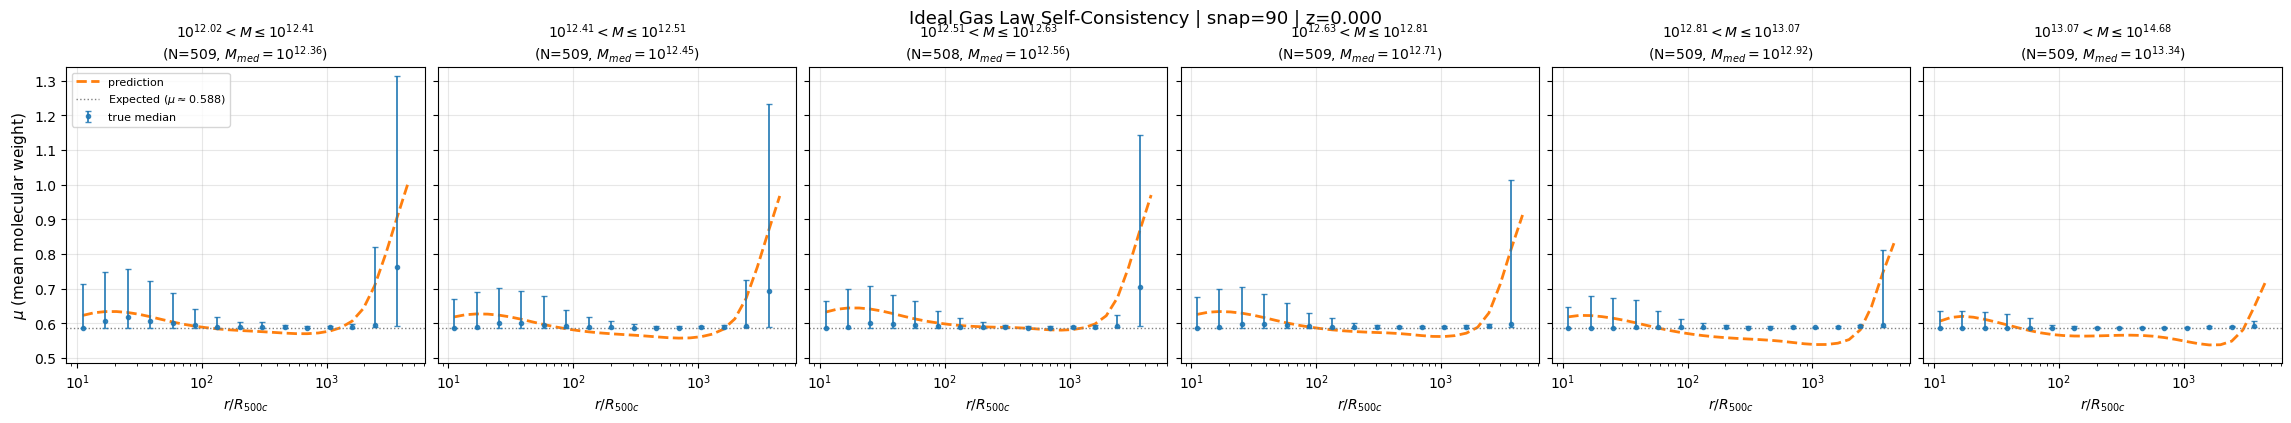

In [10]:
# Ideal gas law: P = (rho / mu*m_p) * k_B * T
# We recover the mean molecular weight mu = k_B / (m_p * C) where C = P / (rho * T).
# This is more intuitive than log10(C). The conversion is monotonically decreasing,
# so quantile ordering flips: q05(logC) -> q95(mu), etc.
# Expected mu ~ 0.588 for fully ionized primordial plasma (XH=0.76).

# k_B / m_p in the same mixed units used in generate_profiles_cy_mpi.py
# (k_B in SI J/K, m_p in SI kg, rho in g/cm3, T stored in keV as a number).
_KB_OVER_MP = 1.380649e-23 / 1.67262192e-27   # ≈ 8255; mu = _KB_OVER_MP / 10^logC

def _logC_to_mu(logC):
    """Convert log10(C) to mean molecular weight mu = k_B / (m_p * C)."""
    return _KB_OVER_MP * 10.0 ** (-logC)

_ig_fields = ('gas_density', 'temperature', 'pressure')
_ig_ok = all(f in CV_FIELDS for f in _ig_fields)

if not _ig_ok:
    print(f'Skipped — need gas_density, temperature, pressure in CV_FIELDS={CV_FIELDS}')
else:
    def _ig_logC(profiles, mask=None):
        """Compute log10(C) = log10(P) - log10(rho) - log10(T)."""
        eps = 1e-30
        arr = (np.log10(np.clip(profiles['pressure'], eps, None))
               - np.log10(np.clip(profiles['gas_density'], eps, None))
               - np.log10(np.clip(profiles['temperature'], eps, None)))
        return arr if mask is None else arr[mask]

    _logm_start = 12.0
    _n_mass_bins = 6
    _min_count = 20

    for i_snap, snap in enumerate(cv_snaps_available):
        z_snap = float(training_redshift_by_snap.get(snap, np.nan))
        preds_snap = cv_predictions_by_snap[snap]
        tags = sorted(preds_snap.keys())

        # ---- Gather masses, R500c, radial grid, and logC for all halos ----
        all_logm, all_masses, all_r500c, all_logC_true = [], [], [], []
        radial_ref = None
        for tag in tags:
            entry = preds_snap[tag]
            mass = np.asarray(entry['M500c'], dtype=np.float64)
            r500 = np.asarray(entry['R500c'], dtype=np.float64)
            all_masses.append(mass)
            all_r500c.append(r500)
            all_logm.append(np.log10(np.clip(mass, 1e-30, None)))
            all_logC_true.append(_ig_logC(entry['true_profiles']))
            if radial_ref is None:
                radial_ref = np.asarray(entry['radial_bins'], dtype=np.float64)

        all_logm = np.concatenate(all_logm)
        all_masses = np.concatenate(all_masses)
        all_r500c = np.concatenate(all_r500c)
        all_logC_true = np.vstack(all_logC_true)   # (N_halos, n_r)

        # ---- Build mass bins ----
        pool = all_logm[all_logm >= _logm_start]
        if pool.size < max(2, _n_mass_bins):
            pool = all_logm.copy()
        edges = np.unique(np.quantile(pool, np.linspace(0, 1, _n_mass_bins + 1)))
        if edges.size < _n_mass_bins + 1:
            lo_e = max(_logm_start, float(np.nanmin(all_logm)))
            hi_e = float(np.nanmax(all_logm))
            edges = np.linspace(lo_e, hi_e if hi_e > lo_e else lo_e + 0.2, _n_mass_bins + 1)
        n_bins = len(edges) - 1

        bin_info = []
        for i_bin in range(n_bins):
            lo_e, hi_e = edges[i_bin], edges[i_bin + 1]
            sel = (all_logm >= lo_e) & (all_logm <= hi_e if i_bin == n_bins - 1 else all_logm < hi_e)
            if int(np.sum(sel)) < _min_count:
                continue
            bin_info.append({
                'lo': lo_e, 'hi': hi_e,
                'n_halos': int(np.sum(sel)),
                'med_mass': float(np.median(all_masses[sel])),
                'med_r500': float(np.median(all_r500c[sel])),
                'logC_true': all_logC_true[sel],   # (n_bin_halos, n_r)
            })

        if len(bin_info) == 0:
            print(f'[snap={snap}] No bins satisfy N >= {_min_count}.')
            continue

        # ---- Run emulator: one halo per bin ----
        single_masses = np.array([b['med_mass'] for b in bin_info], dtype=np.float32)
        single_r500 = np.array([b['med_r500'] for b in bin_info], dtype=np.float64)
        single_rr500 = (radial_ref[None, :] / np.maximum(single_r500[:, None], 1e-12)).astype(np.float32)

        pred = emu.predict(
            theta=theta_fid,
            M=single_masses,
            r_bins=single_rr500,
            field=list(_ig_fields),
            snapnum=int(snap),
            redshift=z_snap,
            n_samples=CV_NSAMPLES,
        )

        fn = list(pred.field_names)
        pred_profiles_mean = {fld: pred.mean[:, :, fn.index(fld)] for fld in _ig_fields}
        logC_pred_bins = _ig_logC(pred_profiles_mean)   # (n_bins, n_r)

        # ---- Convert logC -> mu for display (monotone decreasing, so quantiles flip) ----
        all_mu_true = _logC_to_mu(all_logC_true)

        # ---- Compute shared y-axis limits from all true mu values (clipped) ----
        _ylo = float(np.nanpercentile(all_mu_true, 1))
        _yhi = float(np.nanpercentile(all_mu_true, 99))
        _pad = 0.15 * (_yhi - _ylo)
        _ylim = (_ylo - _pad, _yhi + _pad)

        # ---- Plot: one column per mass bin ----
        n_cols = len(bin_info)
        fig, axes = plt.subplots(
            1, n_cols,
            figsize=(3.8 * n_cols, 4.0),
            constrained_layout=True,
        )
        if n_cols == 1:
            axes = np.array([axes])

        step = max(1, radial_ref.size // 14)
        idx = np.arange(0, radial_ref.size, step)

        for j_col, binfo in enumerate(bin_info):
            ax_rad = axes[j_col]

            logC_t = binfo['logC_true']   # (n_bin_halos, n_r)
            logC_p = logC_pred_bins[j_col]  # (n_r,)

            # Convert to mu (decreasing transform — quantiles flip).
            mu_p = _logC_to_mu(logC_p)
            mu_t = _logC_to_mu(logC_t)

            # True: median + 1-sigma (16-84%) errorbars in mu space.
            # Because mu = f(logC) is decreasing, quantile ordering is preserved.
            med  = np.median(mu_t, axis=0)
            q16  = np.quantile(mu_t, 0.16, axis=0)
            q84  = np.quantile(mu_t, 0.84, axis=0)

            ax_rad.errorbar(
                radial_ref[idx], med[idx],
                yerr=[med[idx] - q16[idx], q84[idx] - med[idx]],
                fmt='o', ms=3.0, color='tab:blue', ecolor='tab:blue',
                elinewidth=1.4, capsize=2.2, alpha=0.85, zorder=3,
                label='true median',
            )

            # Emulator prediction line.
            ax_rad.plot(radial_ref, mu_p, ls='--', color='tab:orange',
                        lw=2.0, label='prediction')
            ax_rad.axhline(0.588, ls=':', color='grey', lw=1.0,
                           label=r'Expected ($\mu\approx0.588$)')

            ax_rad.set_xscale('log')
            ax_rad.set_ylim(_ylim)
            ax_rad.set_title(
                rf'$10^{{{binfo["lo"]:.2f}}} < M \leq 10^{{{binfo["hi"]:.2f}}}$'
                f'\n(N={binfo["n_halos"]}, '
                rf'$M_{{med}}=10^{{{np.log10(binfo["med_mass"]):.2f}}}$)',
                fontsize=10,
            )
            ax_rad.set_xlabel(r'$r/R_{500c}$', fontsize=10)
            if j_col == 0:
                ax_rad.set_ylabel(r'$\mu$ (mean molecular weight)', fontsize=11)
                ax_rad.legend(fontsize=8)
            else:
                ax_rad.tick_params(labelleft=False)
            ax_rad.grid(True, alpha=0.3)

        fig.suptitle(
            f'Ideal Gas Law Self-Consistency | snap={snap} | z={z_snap:.3f}',
            fontsize=13, y=1.02,
        )
        plt.show()

## MAP inference on observed temperature profiles

Load the observed X-ray temperature profiles (same preprocessing as `nuts_temperature_results_review.ipynb`) and fit the emulator parameters by MAP (maximum a posteriori) optimisation using Adam + backprop through `predict_log10_differentiable`.  This is a quick sanity-check of whether the emulator can reproduce the observed stacked profile before committing to a full NUTS run.

In [11]:
# ── Load observed kT profiles ──────────────────────────────────────────────────
# Same paths / preprocessing as run_nuts_temperature.py defaults.
import sys; sys.path.insert(0, str(Path('..').resolve()))
from run_nuts_temperature import load_temperature_profiles

KT_DIR            = Path('/mnt/home/mlee1/CPGP_xray/Data/data/kT')
CATALOG_PATH      = Path('/mnt/home/mlee1/CPGP_xray/Data/clusters.txt')
ONEP_CSV          = Path('/mnt/home/mlee1/Sims/IllustrisTNG/L50n512/1P/'
                         'CosmoAstroSeed_IllustrisTNG_L50n512_1P.txt')
RR500_NBIN_MAP    = 24        # match emulator training radial binning
SIGMA_FLOOR_FRAC  = 0.25      # 25 % fractional floor on temperature error

obs_kT = load_temperature_profiles(
    kt_dir=KT_DIR,
    catalog_path=CATALOG_PATH,
    rr500_nbin=RR500_NBIN_MAP,
    sigma_floor_frac=SIGMA_FLOOR_FRAC,
)
print(f'Clusters loaded : {len(obs_kT.names)}')
print(f'Median valid bins: {float(np.median(obs_kT.valid_counts)):.1f}')

# ── theta fiducial and prior bounds from 1P parameter table ───────────────────
onep_map = pd.read_csv(ONEP_CSV, sep=r'\s+', engine='python')
if '#Name' in onep_map.columns:
    onep_map = onep_map.rename(columns={'#Name': 'tag'})

theta_cols_map = [
    c for c in onep_map.columns
    if c != 'tag'
    and pd.api.types.is_numeric_dtype(onep_map[c])
    and str(c).strip().lower() != 'seed'
][:emu.theta_dim]

fid_mask = onep_map['tag'].str.contains('fiducial', case=False, na=False)
theta_fid_map = (
    onep_map.loc[fid_mask].iloc[0][theta_cols_map].to_numpy(dtype=np.float64)
    if fid_mask.any() else onep_map[theta_cols_map].median().to_numpy(dtype=np.float64)
)
prior_lo_map = np.array([onep_map[c].min() for c in theta_cols_map], dtype=np.float64)
prior_hi_map = np.array([onep_map[c].max() for c in theta_cols_map], dtype=np.float64)

print(f'theta_dim : {emu.theta_dim}')
print(f'fiducial  : {theta_fid_map}')


Loaded 54 matched halos from /mnt/home/mlee1/CPGP_xray/Data/data/kT
Missing catalog matches: 2
Median valid bins per halo: 14.0
Clusters loaded : 54
Median valid bins: 14.0
theta_dim : 35
fiducial  : [ 3.000e-01  8.000e-01  3.600e+00  1.000e+00  7.400e+00  2.000e+01
  4.900e-02  6.711e-01  9.624e-01  2.270e+00  3.000e-01 -2.300e+00
  8.000e+00  1.000e-01  0.000e+00  5.000e-02  3.500e+02  2.500e-01
  2.000e-03  2.000e+00  6.000e-01  8.000e-05  1.000e+00  1.000e+00
  1.000e-01  2.000e-01  2.000e-03  2.000e+00  1.000e+00  0.000e+00
  1.000e+00  0.000e+00  1.300e-03  1.120e+00  2.000e+00]


In [12]:
# ── MAP optimisation ───────────────────────────────────────────────────────────
# Minimises NLL (Gaussian in log10-temperature) w.r.t. to the free parameters
# while keeping all other parameters pinned at their fiducial values.
#
# free_idxs choices (mirror NUTS free-sets):
#   [2,3,4,5]       — 4-param: ASN1, AAGN1, ASN2, AAGN2
#   list(range(6))  — 6-param: above + Omega_m, sigma_8
#   list(range(35)) — all 35

def run_map_fit(
    emulator,
    obs,
    theta_fid: np.ndarray,
    prior_lo: np.ndarray,
    prior_hi: np.ndarray,
    free_idxs,
    n_halos: int = 16,
    halo_indices=None,
    n_steps: int = 600,
    lr: float = 0.01,
    include_model_err: bool = True,
    seed: int = 0,
):
    import torch
    torch.manual_seed(seed)
    device = emulator.device

    # Pick halos for this MAP fit.
    if halo_indices is None:
        order = np.argsort(obs.valid_counts)[::-1]
        batch_idxs = order[:min(int(n_halos), len(order))]
    else:
        batch_idxs = np.asarray(halo_indices, dtype=int).ravel()
        if batch_idxs.size == 0:
            raise ValueError('halo_indices was provided but is empty.')
        n_obs = len(obs.names)
        if np.any((batch_idxs < 0) | (batch_idxs >= n_obs)):
            raise IndexError(f'halo_indices must lie in [0, {n_obs - 1}]. Got {batch_idxs}.')

    y_t   = torch.tensor(obs.y_obs_log[batch_idxs, :, 0],     dtype=torch.float64, device=device)
    sig_t = torch.tensor(obs.sigma_obs_log[batch_idxs, :, 0], dtype=torch.float64, device=device)
    mask_t = torch.isfinite(y_t) & torch.isfinite(sig_t) & (sig_t < 1e5)
    if not bool(mask_t.any()):
        raise ValueError('No valid observed bins available for MAP fit.')

    # IMPORTANT: slice to valid bins once, then do all arithmetic on valid tensors.
    # Computing residuals on full tensors and masking afterward can leak NaNs from
    # invalid bins into autograd when total_std depends on theta.
    y_valid = y_t[mask_t]
    sig_valid = sig_t[mask_t]

    m_batch = obs.m500[batch_idxs]
    r_batch = obs.r_bins[batch_idxs]

    # Initialise theta as a full nn.Parameter at fiducial; grad masked for fixed params
    theta_dim  = emulator.theta_dim
    free_idxs  = list(free_idxs)
    fixed_idxs = [i for i in range(theta_dim) if i not in free_idxs]

    theta_param = torch.nn.Parameter(
        torch.tensor(theta_fid.astype(np.float32), device=device)
    )
    # Gradient mask: 1.0 for free, 0.0 for fixed
    grad_mask = torch.zeros(theta_dim, dtype=torch.float32, device=device)
    grad_mask[free_idxs] = 1.0

    lo_t = torch.tensor(prior_lo.astype(np.float32), device=device)
    hi_t = torch.tensor(prior_hi.astype(np.float32), device=device)

    optimizer = torch.optim.Adam([theta_param], lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_steps, eta_min=lr * 0.05)

    losses = []
    for step in range(n_steps):
        optimizer.zero_grad()

        mu_log10, std_log10 = emulator.predict_log10_differentiable(
            theta=theta_param,
            M=m_batch,
            r_bins=r_batch,
            field=['temperature'],
            snapnum=90,
            redshift=0.0,
            n_samples=1,
            deterministic=True,
        )
        mu = mu_log10[..., 0].to(torch.float64)
        std_model = std_log10[..., 0].to(torch.float64).clamp_min(1e-12)

        mu_valid = mu[mask_t]
        std_valid = std_model[mask_t]

        if include_model_err:
            total_var = (sig_valid ** 2 + std_valid ** 2).clamp_min(1e-30)
        else:
            total_var = sig_valid.clamp_min(1e-12) ** 2

        total_std = torch.sqrt(total_var)
        residuals = (y_valid - mu_valid) / total_std
        # Gaussian NLL (per valid bin, mean over batch)
        nll = 0.5 * (residuals ** 2).mean() + torch.log(total_std).mean()
        nll.backward()

        # Zero gradients for fixed parameters, then clip free ones
        with torch.no_grad():
            theta_param.grad.mul_(grad_mask)
        torch.nn.utils.clip_grad_norm_([theta_param], max_norm=5.0)
        optimizer.step()

        # Clamp free parameters to prior
        with torch.no_grad():
            clamped = theta_param.data.clone()
            clamped[free_idxs] = clamped[free_idxs].clamp(lo_t[free_idxs], hi_t[free_idxs])
            # Restore fixed params exactly (Adam can drift them by a tiny amount)
            clamped[fixed_idxs] = torch.tensor(theta_fid.astype(np.float32), device=device)[fixed_idxs]
            theta_param.data.copy_(clamped)

        scheduler.step()
        losses.append(float(nll.detach()))

    theta_map = theta_param.detach().cpu().numpy().astype(np.float64)
    return {
        'theta_map'  : theta_map,
        'losses'     : losses,
        'batch_idxs' : batch_idxs,
        'free_idxs'  : free_idxs,
        'batch_names': [str(obs.names[i]) for i in batch_idxs],
    }

print('run_map_fit() defined.')


run_map_fit() defined.


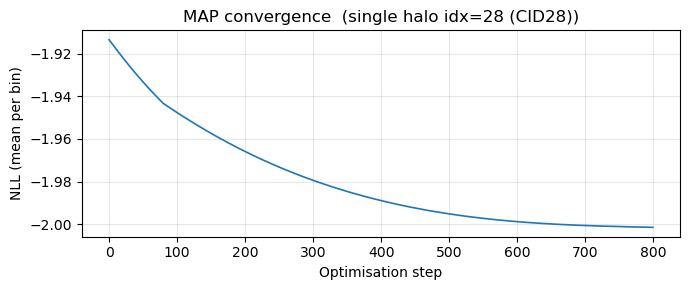


MAP fitted halo(s):
  idx= 28  name=CID28

MAP parameter estimates (free params only):
  [ 2] WindEnergyIn1e51erg                       fid=3.6  MAP=7.461  prior=[0.9, 14.4]
  [ 3] RadioFeedbackFactor                       fid=1  MAP=0.25  prior=[0.25, 4]
  [ 4] VariableWindVelFactor                     fid=7.4  MAP=9.339  prior=[3.7, 14.8]
  [ 5] RadioFeedbackReiorientationFactor         fid=20  MAP=16.16  prior=[10, 40]


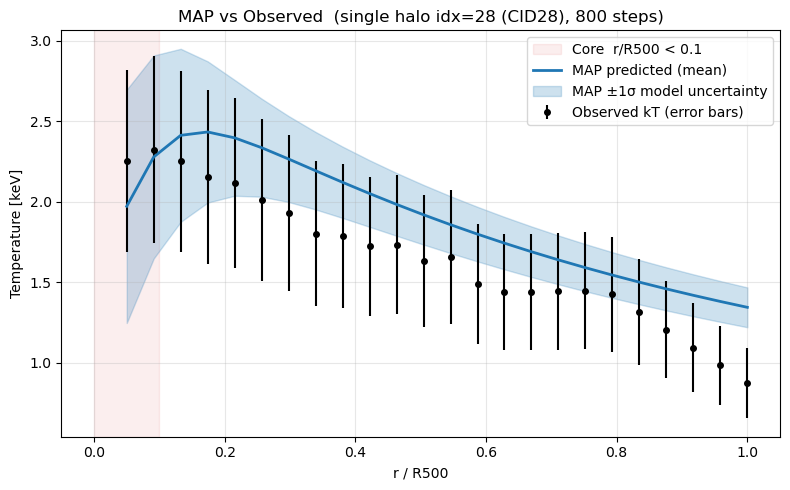


Total-profile RMSE = 0.2844 keV
Core-region bias   = -0.1626 keV  (r/R500 < 0.1, positive = over-predicted)


In [13]:
# ── Run MAP + plot predicted vs observed ──────────────────────────────────────
# Choose which parameters to fit here:
MAP_FREE_IDXS = [2, 3, 4, 5]   # 4-param ASN/AAGN; change to list(range(35)) for all

# Set MAP_SINGLE_HALO_INDEX to an integer for single-halo MAP.
# Set to None to use the stacked mode with N_HALOS_MAP best-sampled halos.
MAP_SINGLE_HALO_INDEX = int(np.argsort(obs_kT.valid_counts)[::-1][0])
N_HALOS_MAP = 16

N_STEPS_MAP = 800
LR_MAP = 0.01
INCLUDE_MODEL_ERR = True

if MAP_SINGLE_HALO_INDEX is None:
    map_halo_indices = None
    n_halos_fit = N_HALOS_MAP
    map_mode_label = f'stacked top-{n_halos_fit} halos'
else:
    map_halo_indices = [int(MAP_SINGLE_HALO_INDEX)]
    n_halos_fit = 1
    map_mode_label = f'single halo idx={MAP_SINGLE_HALO_INDEX} ({obs_kT.names[MAP_SINGLE_HALO_INDEX]})'

map_result = run_map_fit(
    emu,
    obs_kT,
    theta_fid=theta_fid_map,
    prior_lo=prior_lo_map,
    prior_hi=prior_hi_map,
    free_idxs=MAP_FREE_IDXS,
    n_halos=n_halos_fit,
    halo_indices=map_halo_indices,
    n_steps=N_STEPS_MAP,
    lr=LR_MAP,
    include_model_err=INCLUDE_MODEL_ERR,
)

# ── Loss curve ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(map_result['losses'], color='tab:blue', lw=1.2)
ax.set_xlabel('Optimisation step')
ax.set_ylabel('NLL (mean per bin)')
ax.set_title(f'MAP convergence  ({map_mode_label})')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nMAP fitted halo(s):')
for i, name in zip(map_result['batch_idxs'], map_result['batch_names']):
    print(f'  idx={int(i):3d}  name={name}')

# ── MAP parameter values ──────────────────────────────────────────────────────
print('\nMAP parameter estimates (free params only):')
for idx in map_result['free_idxs']:
    name = theta_cols_map[idx] if idx < len(theta_cols_map) else f'param_{idx}'
    lo, hi = prior_lo_map[idx], prior_hi_map[idx]
    print(f'  [{idx:2d}] {name:40s}  fid={theta_fid_map[idx]:.4g}  '
          f'MAP={map_result["theta_map"][idx]:.4g}'
          f'  prior=[{lo:.4g}, {hi:.4g}]')

# ── Predicted vs observed stacked/single profile ─────────────────────────────
batch_idxs = map_result['batch_idxs']
y_obs = obs_kT.y_obs_log[batch_idxs, :, 0]
sig_obs = obs_kT.sigma_obs_log[batch_idxs, :, 0]
valid = np.isfinite(y_obs) & np.isfinite(sig_obs) & (sig_obs < 1e5)

# Predicted profiles at MAP theta
pred_map = emu.predict(
    theta=map_result['theta_map'],
    M=obs_kT.m500[batch_idxs],
    r_bins=obs_kT.r_bins[batch_idxs],
    field=['temperature'],
    snapnum=90,
    redshift=0.0,
    n_samples=50,
)

# API returns mean in physical units (keV); mean_log10/std_log10 stay in log10 space.
pred_mu_keV = pred_map.mean[:, :, 0]              # (n_halo, n_r) keV
pred_mu_log = pred_map.mean_log10[:, :, 0]        # (n_halo, n_r) log10 keV
pred_std_log = pred_map.std_log10[:, :, 0]        # (n_halo, n_r) log10 keV

# Observed profile in linear keV
n_eff = np.sum(valid, axis=0)
min_support = 1 if len(batch_idxs) == 1 else 3
support = n_eff >= min_support
obs_stack = np.where(valid, np.power(10.0, y_obs), np.nan)
obs_mean_keV = np.nanmean(obs_stack, axis=0)

if len(batch_idxs) == 1:
    # For a single halo, use the per-bin measurement uncertainty.
    obs_sem_keV = np.full_like(obs_mean_keV, np.nan, dtype=np.float64)
    obs_sem_keV[support] = obs_mean_keV[support] * np.log(10.0) * sig_obs[0, support]
else:
    # For stacked halos, show uncertainty on the stacked mean.
    obs_sem_keV = np.nanstd(obs_stack, axis=0) / np.sqrt(np.clip(n_eff, 1, None))
obs_mean_keV[~support] = np.nan

# Predicted profile (linear keV) — mean and ±1σ band
pred_mean_keV = np.nanmean(np.where(valid, pred_mu_keV, np.nan), axis=0)
# Propagate model std into linear space: δT ≈ T * ln(10) * σ_log10
pred_sd_keV = pred_mu_keV * np.log(10) * pred_std_log
pred_lo_keV = np.nanmean(np.where(valid, pred_mu_keV - pred_sd_keV, np.nan), axis=0)
pred_hi_keV = np.nanmean(np.where(valid, pred_mu_keV + pred_sd_keV, np.nan), axis=0)
pred_mean_keV[~support] = np.nan

rr = obs_kT.r_bins[0]
fig, ax = plt.subplots(figsize=(8, 5))
ax.axvspan(0, 0.1, color='tab:red', alpha=0.08, label='Core  r/R500 < 0.1')
ax.errorbar(rr[support], obs_mean_keV[support], yerr=obs_sem_keV[support],
            fmt='o', ms=4, color='black', label='Observed kT (error bars)')
ax.plot(rr[support], pred_mean_keV[support], lw=2.0, color='tab:blue',
        label='MAP predicted (mean)')
ax.fill_between(rr[support], pred_lo_keV[support], pred_hi_keV[support],
                color='tab:blue', alpha=0.22, label='MAP ±1σ model uncertainty')
ax.set_xlabel('r / R500')
ax.set_ylabel('Temperature [keV]')
ax.set_title(f'MAP vs Observed  ({map_mode_label}, {N_STEPS_MAP} steps)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Residuals
mask_eval = support & np.isfinite(obs_mean_keV) & np.isfinite(pred_mean_keV)
rmse = float(np.sqrt(np.nanmean((obs_mean_keV[mask_eval] - pred_mean_keV[mask_eval]) ** 2)))
core = mask_eval & (rr < 0.1)
core_bias = float(np.nanmean(pred_mean_keV[core] - obs_mean_keV[core])) if core.any() else np.nan
print(f'\nTotal-profile RMSE = {rmse:.4f} keV')
print(f'Core-region bias   = {core_bias:+.4f} keV  (r/R500 < 0.1, positive = over-predicted)')


In [14]:
# Optional: sweep single-halo MAP across a diverse halo subset.

def run_single_halo_map_sweep(
    emulator,
    obs,
    theta_fid,
    prior_lo,
    prior_hi,
    free_idxs,
    halo_indices,
    n_steps=300,
    lr=0.01,
    include_model_err=True,
    snapnum=90,
    redshift=0.0,
    pred_samples=30,
):
    rows = []
    for i_halo in np.asarray(halo_indices, dtype=int):
        res = run_map_fit(
            emulator,
            obs,
            theta_fid=theta_fid,
            prior_lo=prior_lo,
            prior_hi=prior_hi,
            free_idxs=free_idxs,
            n_halos=1,
            halo_indices=[int(i_halo)],
            n_steps=int(n_steps),
            lr=float(lr),
            include_model_err=bool(include_model_err),
            seed=0,
        )

        hidx = int(res['batch_idxs'][0])
        y_obs = obs.y_obs_log[hidx, :, 0]
        sig_obs = obs.sigma_obs_log[hidx, :, 0]
        valid = np.isfinite(y_obs) & np.isfinite(sig_obs) & (sig_obs < 1e5)

        pred = emulator.predict(
            theta=res['theta_map'],
            M=obs.m500[[hidx]],
            r_bins=obs.r_bins[[hidx]],
            field=['temperature'],
            snapnum=int(snapnum),
            redshift=float(redshift),
            n_samples=int(pred_samples),
        )
        pred_keV = np.asarray(pred.mean[0, :, 0], dtype=np.float64)
        obs_keV = np.power(10.0, np.asarray(y_obs, dtype=np.float64))

        mask = valid & np.isfinite(pred_keV) & np.isfinite(obs_keV)
        if np.any(mask):
            rmse = float(np.sqrt(np.nanmean((pred_keV[mask] - obs_keV[mask]) ** 2)))
        else:
            rmse = np.nan

        rr = np.asarray(obs.r_bins[hidx], dtype=np.float64)
        core_mask = mask & (rr < 0.1)
        core_bias = float(np.nanmean(pred_keV[core_mask] - obs_keV[core_mask])) if np.any(core_mask) else np.nan

        rows.append({
            'halo_idx': hidx,
            'halo_name': str(obs.names[hidx]),
            'valid_bins': int(np.sum(valid)),
            'final_nll': float(res['losses'][-1]) if len(res['losses']) else np.nan,
            'rmse_keV': rmse,
            'core_bias_keV': core_bias,
            'theta_map': res['theta_map'],
        })

    out = pd.DataFrame(rows)
    if len(out):
        out = out.sort_values('rmse_keV').reset_index(drop=True)
    return out


# Pick a diverse subset by spanning valid-bin rank from best to worst sampled halos.
order_valid = np.argsort(obs_kT.valid_counts)[::-1]
n_eval = min(8, len(order_valid))
rank_positions = np.linspace(0, len(order_valid) - 1, n_eval).astype(int)
diverse_halo_idxs = order_valid[rank_positions]

print('Evaluating single-halo MAP for indices:', diverse_halo_idxs.tolist())

single_halo_sweep_df = run_single_halo_map_sweep(
    emu,
    obs_kT,
    theta_fid=theta_fid_map,
    prior_lo=prior_lo_map,
    prior_hi=prior_hi_map,
    free_idxs=MAP_FREE_IDXS,
    halo_indices=diverse_halo_idxs,
    n_steps=300,
    lr=LR_MAP,
    include_model_err=INCLUDE_MODEL_ERR,
    snapnum=90,
    redshift=0.0,
    pred_samples=30,
)

display(single_halo_sweep_df[['halo_idx', 'halo_name', 'valid_bins', 'final_nll', 'rmse_keV', 'core_bias_keV']])

if len(single_halo_sweep_df):
    print('Median RMSE across sweep halos: {:.4f} keV'.format(float(single_halo_sweep_df['rmse_keV'].median())))
    print('RMSE range: [{:.4f}, {:.4f}] keV'.format(
        float(single_halo_sweep_df['rmse_keV'].min()),
        float(single_halo_sweep_df['rmse_keV'].max()),
    ))

Evaluating single-halo MAP for indices: [28, 9, 18, 12, 17, 0, 14, 44]


,halo_idx,halo_name,valid_bins,final_nll,rmse_keV,core_bias_keV
0,28,CID28,24,-1.959840,0.308923,-0.070228
1,9,A1185,17,-1.701655,0.498532,0.334778
2,17,A2877,14,-1.895484,0.523966,-0.588264
3,18,A3341,16,-1.749026,0.596759,0.407939
4,44,RXCJ1840.6-7709,4,2.107650,1.069297,0.839553
5,12,A2147,15,-1.463691,1.464716,1.385885
6,14,A2199,10,-0.070634,3.141426,3.111394
7,0,2A0335,12,2.283323,4.168565,4.537876


Median RMSE across sweep halos: 0.8330 keV
RMSE range: [0.3089, 4.1686] keV


Running single-halo MAP for top halos: [28, 6, 20, 29, 19, 24, 39, 9, 27, 40, 38, 53, 1, 7, 16, 18]


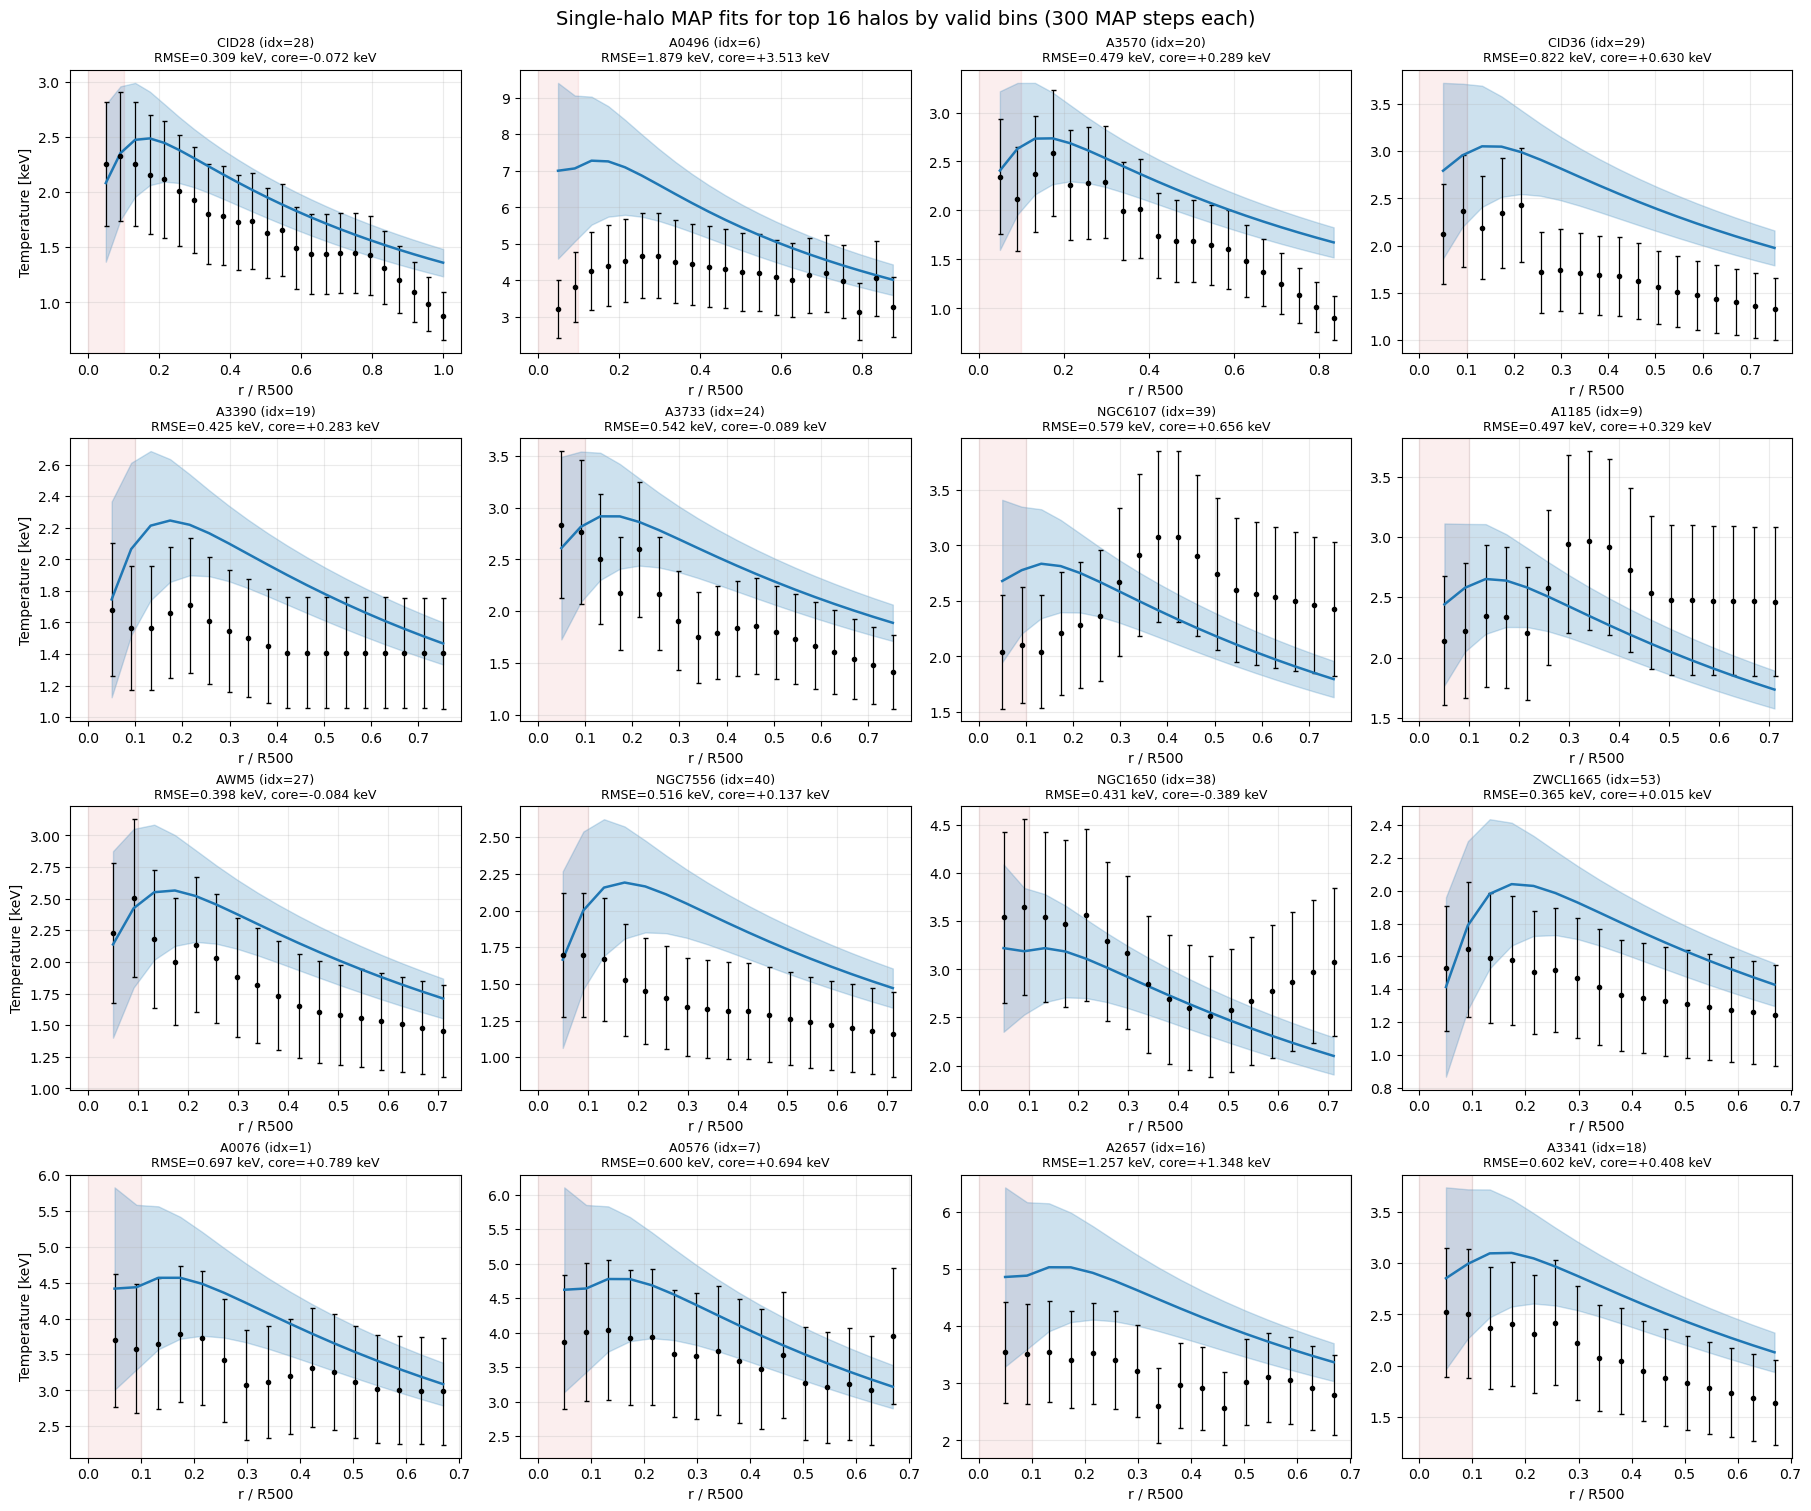

,halo_idx,halo_name,valid_bins,final_nll,rmse_keV,core_bias_keV
0,28,CID28,24,-1.959840,0.309971,-0.070530
1,6,A0496,21,-1.426370,1.885221,3.527602
2,20,A3570,20,-1.636617,0.482122,0.290579
3,29,CID36,18,-1.182725,0.822468,0.632417
4,19,A3390,18,-1.747122,0.430571,0.288139
5,24,A3733,18,-1.792837,0.542056,-0.084322
6,39,NGC6107,18,-1.617882,0.578452,0.658800
7,9,A1185,17,-1.701655,0.497733,0.332897
8,27,AWM5,17,-1.930303,0.391899,-0.084100
9,40,NGC7556,17,-1.523587,0.520265,0.140829


In [15]:
# 16-panel single-halo MAP diagnostics (one independent MAP fit per halo)

TOP16_N = 16
TOP16_STEPS = 300      # increase to 800 for tighter per-halo convergence
TOP16_PRED_SAMPLES = 40

order_valid = np.argsort(obs_kT.valid_counts)[::-1]
top16_halo_idxs = order_valid[:min(TOP16_N, len(order_valid))]

print('Running single-halo MAP for top halos:', top16_halo_idxs.tolist())

single_halo_top16_df = run_single_halo_map_sweep(
    emu,
    obs_kT,
    theta_fid=theta_fid_map,
    prior_lo=prior_lo_map,
    prior_hi=prior_hi_map,
    free_idxs=MAP_FREE_IDXS,
    halo_indices=top16_halo_idxs,
    n_steps=TOP16_STEPS,
    lr=LR_MAP,
    include_model_err=INCLUDE_MODEL_ERR,
    snapnum=90,
    redshift=0.0,
    pred_samples=TOP16_PRED_SAMPLES,
)

# Restore original top16 order (sweep helper sorts by RMSE).
single_halo_top16_df = (
    single_halo_top16_df
    .set_index('halo_idx')
    .loc[top16_halo_idxs]
    .reset_index()
)


def plot_single_halo_top16_grid(emulator, obs, fit_df, snapnum=90, redshift=0.0, pred_samples=40):
    n_panels = min(16, len(fit_df))
    n_cols = 4
    n_rows = int(np.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 15), constrained_layout=True)
    axes = np.array(axes).reshape(n_rows, n_cols)

    for i_ax in range(n_rows * n_cols):
        ax = axes.flat[i_ax]
        if i_ax >= n_panels:
            ax.axis('off')
            continue

        row = fit_df.iloc[i_ax]
        hidx = int(row['halo_idx'])
        hname = str(row['halo_name'])
        theta_map_i = np.asarray(row['theta_map'], dtype=np.float64)

        y_obs = np.asarray(obs.y_obs_log[hidx, :, 0], dtype=np.float64)
        sig_obs = np.asarray(obs.sigma_obs_log[hidx, :, 0], dtype=np.float64)
        rr = np.asarray(obs.r_bins[hidx], dtype=np.float64)

        valid = np.isfinite(y_obs) & np.isfinite(sig_obs) & (sig_obs < 1e5)
        obs_keV = np.power(10.0, y_obs)
        obs_err_keV = np.full_like(obs_keV, np.nan)
        obs_err_keV[valid] = obs_keV[valid] * np.log(10.0) * sig_obs[valid]

        pred = emulator.predict(
            theta=theta_map_i,
            M=obs.m500[[hidx]],
            r_bins=obs.r_bins[[hidx]],
            field=['temperature'],
            snapnum=int(snapnum),
            redshift=float(redshift),
            n_samples=int(pred_samples),
        )

        pred_mu = np.asarray(pred.mean[0, :, 0], dtype=np.float64)
        if pred.std_log10 is not None:
            pred_sd = pred_mu * np.log(10.0) * np.asarray(pred.std_log10[0, :, 0], dtype=np.float64)
        else:
            pred_sd = np.asarray(pred.total_std[0, :, 0], dtype=np.float64)

        support = valid & np.isfinite(obs_keV) & np.isfinite(pred_mu)
        core = support & (rr < 0.1)

        rmse_i = float(np.sqrt(np.nanmean((pred_mu[support] - obs_keV[support]) ** 2))) if np.any(support) else np.nan
        core_bias_i = float(np.nanmean(pred_mu[core] - obs_keV[core])) if np.any(core) else np.nan

        ax.axvspan(0, 0.1, color='tab:red', alpha=0.08)
        if np.any(support):
            ax.errorbar(
                rr[support], obs_keV[support], yerr=obs_err_keV[support],
                fmt='o', ms=3.0, color='black', ecolor='black', elinewidth=0.9, capsize=1.8
            )
            ax.plot(rr[support], pred_mu[support], lw=1.8, color='tab:blue')
            ax.fill_between(
                rr[support],
                (pred_mu - pred_sd)[support],
                (pred_mu + pred_sd)[support],
                color='tab:blue', alpha=0.22
            )

        ax.set_title(
            f'{hname} (idx={hidx})\nRMSE={rmse_i:.3f} keV, core={core_bias_i:+.3f} keV',
            fontsize=9,
        )
        ax.set_xlabel('r / R500')
        if i_ax % n_cols == 0:
            ax.set_ylabel('Temperature [keV]')
        ax.grid(alpha=0.25)

    fig.suptitle(
        f'Single-halo MAP fits for top {n_panels} halos by valid bins '
        f'({TOP16_STEPS} MAP steps each)',
        fontsize=14,
    )
    plt.show()


plot_single_halo_top16_grid(
    emu,
    obs_kT,
    single_halo_top16_df,
    snapnum=90,
    redshift=0.0,
    pred_samples=TOP16_PRED_SAMPLES,
)

display(single_halo_top16_df[['halo_idx', 'halo_name', 'valid_bins', 'final_nll', 'rmse_keV', 'core_bias_keV']])

In [43]:
# Quick check: training args used by the loaded emulator
print('run_args keys:', sorted(run_args.keys()))
for k in ['profiles_base', 'param_csv', 'suite', 'sim_set', 'resolved_snapnums', 'snapnums', 'snapnum', 'train_frac', 'val_frac', 'seed']:
    if k in run_args:
        print(f'{k}:', run_args[k])

run_args keys: ['accum_steps', 'all_profiles_subset', 'aux_halo_frac', 'batch_size', 'beta_nll_weight', 'cc_dual_head', 'cc_indicator', 'cc_indicator_core_bins', 'cc_indicator_feature_idx', 'channel_balance_alpha', 'channel_balance_eps', 'channel_balance_loss', 'context_dropout_rate', 'context_sensitivity_batches', 'context_sensitivity_every', 'context_sensitivity_samples', 'core_bias_weight', 'core_radius_frac', 'core_radius_min_bins', 'core_radius_weight', 'd_latent', 'd_model', 'ddp_num_workers', 'ddp_timeout_sec', 'dec_hidden', 'dec_layers', 'decoder_likelihood', 'disable_continuous_redshift_feature', 'disable_mean_prior', 'disable_radius_fourier', 'disable_task_uncertainty_weighting', 'dropout', 'early_stop_min_delta', 'enable_data_parallel', 'enable_ddp', 'epochs', 'eps', 'eval_samples', 'fewshot_contexts', 'fewshot_repeats', 'free_bits', 'grad_clip', 'halo_logm_hi', 'halo_logm_lo', 'halo_mass_quantile_idx', 'high_mass_boost', 'high_mass_threshold', 'ideal_gas_weight', 'input_noi

Discovered runs: 1012
Train/Val/Test: 809 101 102
Scanning snaps: [90]
  scanned 100/809 train runs ...
  scanned 200/809 train runs ...
  scanned 300/809 train runs ...
  scanned 400/809 train runs ...
  scanned 500/809 train runs ...
  scanned 600/809 train runs ...
  scanned 700/809 train runs ...
  scanned 800/809 train runs ...
Usable training halos scanned: 107006
Cool-core rising candidates found: 43543


,run_id,halo_idx,m500c,cool_frac,slope,corr,rise_frac,sim_to_ngc6107,score
104158,675,2,1.171587e+14,0.272610,2.909588,0.906812,0.857143,0.217212,0.667892
5199,101,3,3.369567e+13,0.486590,3.191230,0.897145,0.833333,0.221278,1.277013
56386,882,29,1.125842e+13,0.638944,3.150756,0.967737,0.900000,0.254283,1.850796
49065,757,0,2.022709e+13,0.627070,3.135899,0.967434,0.909091,0.264235,1.815917
38135,447,2,1.242770e+14,0.240905,2.872946,0.840149,0.857143,0.269277,0.539939
42452,574,1,3.521598e+13,0.404229,3.499678,0.857335,0.833333,0.272383,1.111777
60637,1008,52,1.496537e+13,0.574109,3.002533,0.887151,0.909091,0.281175,1.459743
252,504,88,9.921143e+12,0.687077,3.123849,0.922724,0.900000,0.282181,1.881443
42289,62,6,2.061021e+13,0.636577,3.471530,0.968592,0.909091,0.301826,2.043194
43015,164,12,3.493255e+13,0.675487,3.160469,0.892280,0.833333,0.304383,1.746147


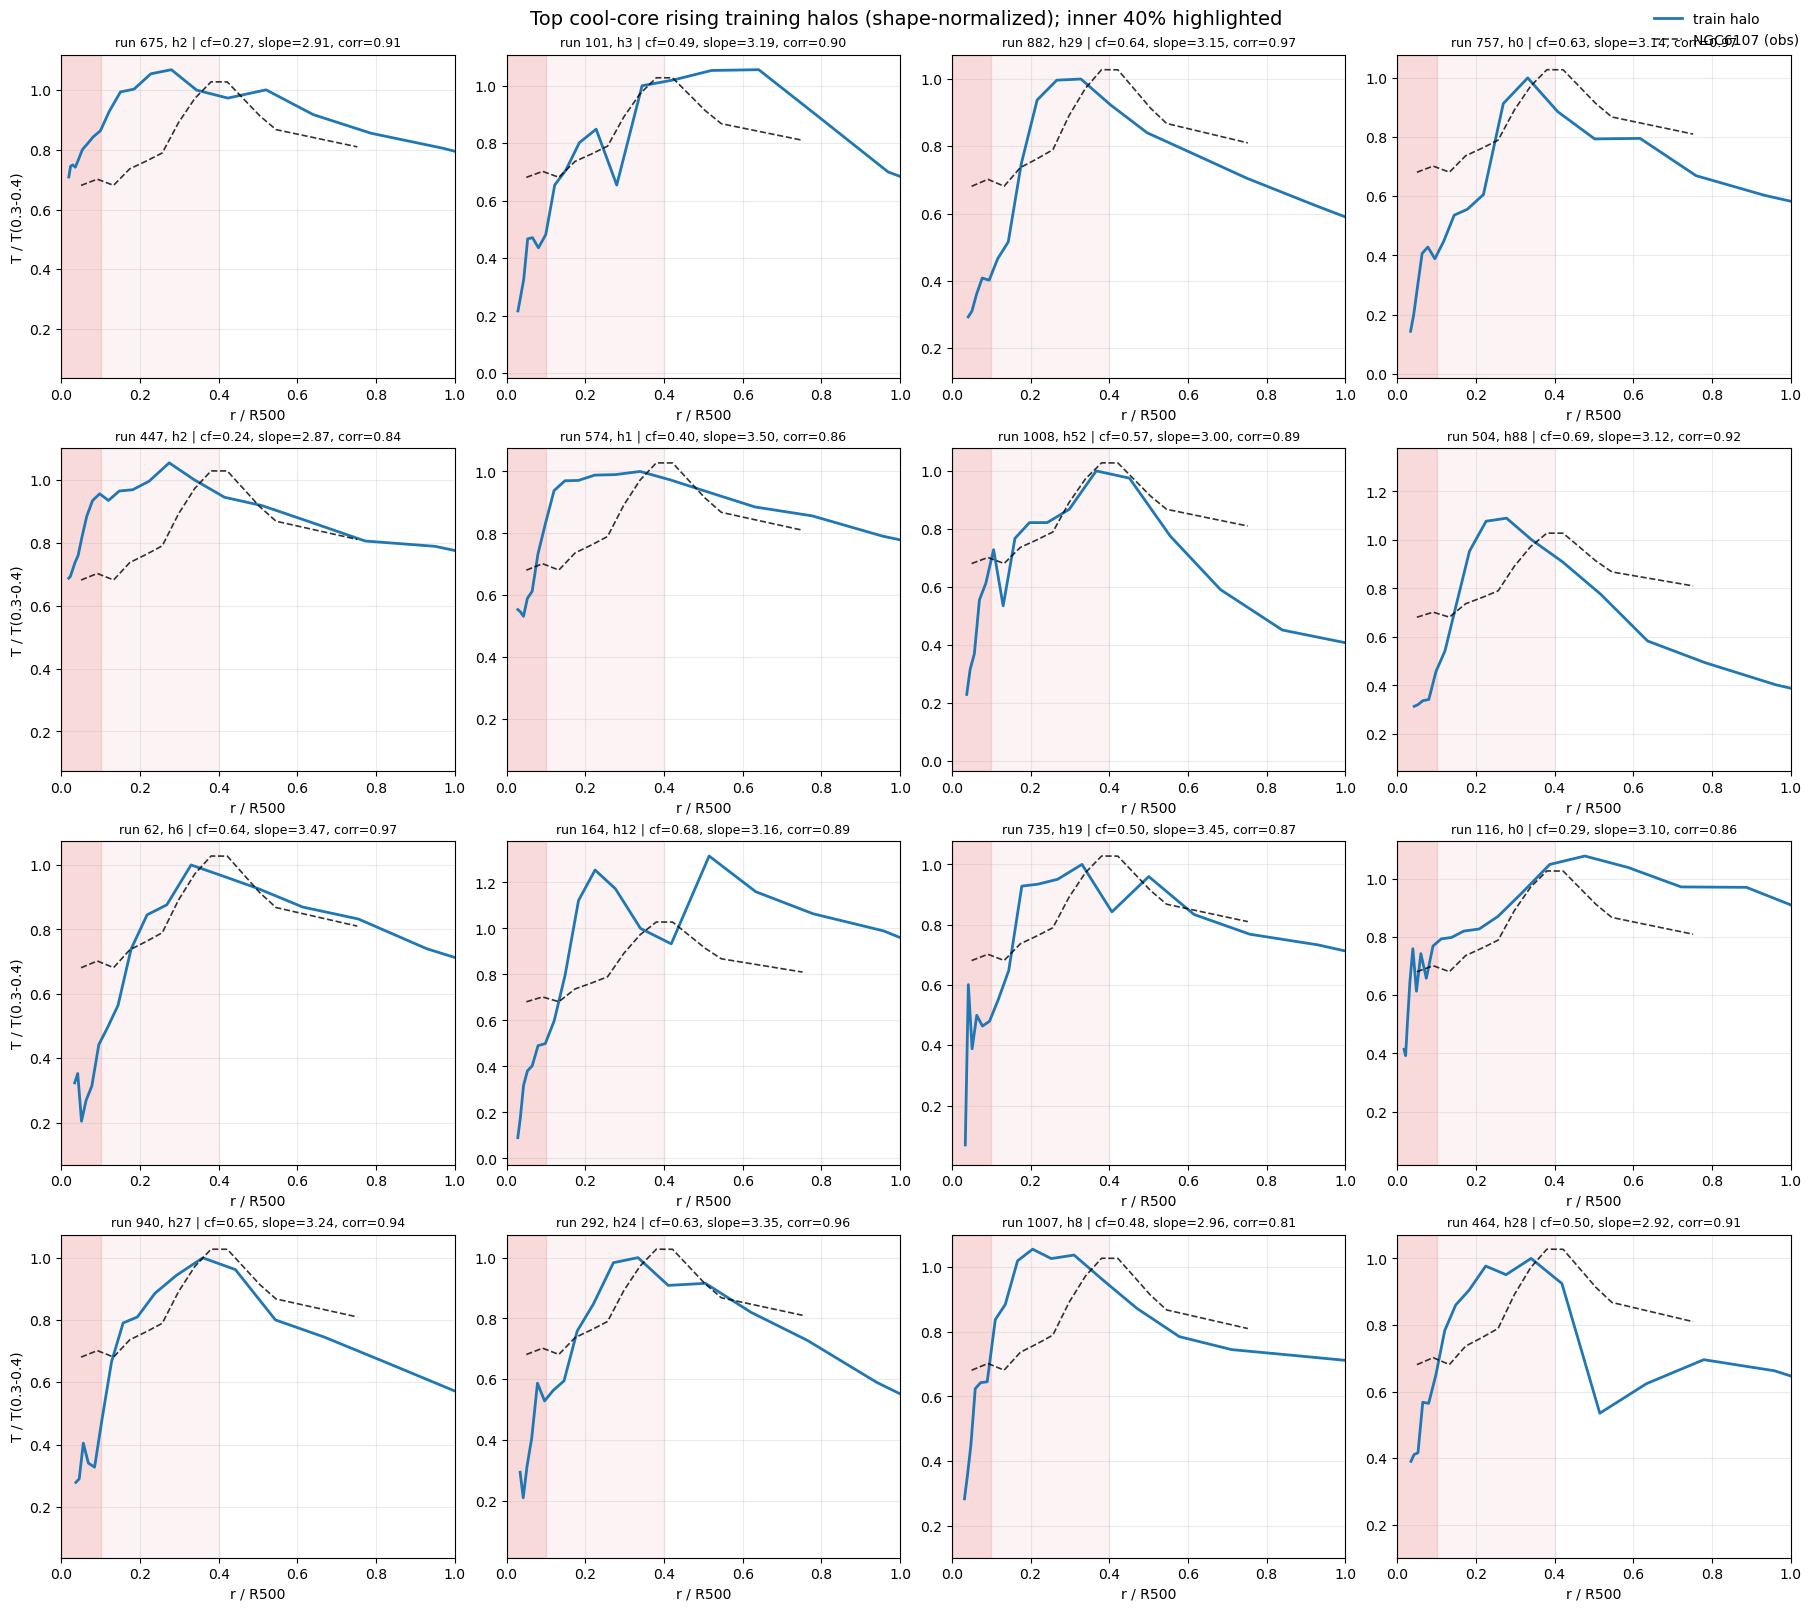

In [44]:
# Find cool-core training halos with rising inner temperature (r/R500 <= 0.4),
# and rank examples similar to NGC6107.
from train_anp_emulator import discover_runs

CC_INNER_MAX = 0.4
CC_CORE_MAX = 0.1
CC_OUTER_MIN = 0.2
CC_MIN_INNER_BINS = 6


def _compute_profile_metrics(rr, t_keV):
    rr = np.asarray(rr, dtype=np.float64)
    t_keV = np.asarray(t_keV, dtype=np.float64)

    valid = np.isfinite(rr) & np.isfinite(t_keV) & (rr > 0) & (t_keV > 0)
    inner = valid & (rr <= CC_INNER_MAX)
    core = valid & (rr <= CC_CORE_MAX)
    outer = valid & (rr >= CC_OUTER_MIN) & (rr <= CC_INNER_MAX)

    if inner.sum() < CC_MIN_INNER_BINS or core.sum() < 2 or outer.sum() < 2:
        return None

    rr_i = rr[inner]
    t_i = t_keV[inner]
    order = np.argsort(rr_i)
    rr_i = rr_i[order]
    t_i = t_i[order]

    # Rising trend metrics in the inner region.
    slope = float(np.polyfit(rr_i, t_i, 1)[0])
    corr = float(np.corrcoef(rr_i, t_i)[0, 1]) if rr_i.size > 1 else np.nan
    rise_frac = float(np.mean(np.diff(t_i) > 0)) if rr_i.size > 2 else np.nan

    t_core = float(np.median(t_keV[core]))
    t_outer = float(np.median(t_keV[outer]))
    cool_frac = float((t_outer - t_core) / max(t_outer, 1e-12))

    # Composite score favors cool center + rising inner trend.
    score = max(cool_frac, 0.0) * max(corr, 0.0) * max(slope, 0.0) * (0.5 + 0.5 * max(rise_frac, 0.0))

    return {
        'n_inner': int(inner.sum()),
        'slope': slope,
        'corr': corr,
        'rise_frac': rise_frac,
        't_core': t_core,
        't_outer': t_outer,
        'cool_frac': cool_frac,
        'score': float(score),
    }


def _split_training_runs_from_args(run_args_dict):
    base_path = Path(run_args_dict['profiles_base'])
    suite = str(run_args_dict['suite'])
    sim_set = str(run_args_dict['sim_set'])
    snapnums = list(run_args_dict.get('resolved_snapnums') or [run_args_dict.get('snapnum')])

    theta_by_run = load_theta_table(Path(run_args_dict['param_csv']), target_theta_dim=int(run_args_dict['theta_dim']))

    discovered = set()
    for snap in snapnums:
        discovered.update(discover_runs(base_path, suite=suite, sim_set=sim_set, snapnum=int(snap)))

    candidate_runs = sorted(r for r in discovered if r in theta_by_run)

    max_runs = int(run_args_dict.get('max_runs', -1) or -1)
    if max_runs > 0:
        candidate_runs = candidate_runs[:max_runs]

    rng = np.random.default_rng(int(run_args_dict.get('seed', 0)))
    idx = rng.permutation(len(candidate_runs))
    n_train = int(len(candidate_runs) * float(run_args_dict.get('train_frac', 0.8)))
    n_val = int(len(candidate_runs) * float(run_args_dict.get('val_frac', 0.1)))

    train_runs = [candidate_runs[i] for i in idx[:n_train]]
    val_runs = [candidate_runs[i] for i in idx[n_train:n_train + n_val]]
    test_runs = [candidate_runs[i] for i in idx[n_train + n_val:]]

    return {
        'base_path': base_path,
        'suite': suite,
        'sim_set': sim_set,
        'snapnums': snapnums,
        'candidate_runs': candidate_runs,
        'train_runs': train_runs,
        'val_runs': val_runs,
        'test_runs': test_runs,
    }


split_info = _split_training_runs_from_args(run_args)
print('Discovered runs:', len(split_info['candidate_runs']))
print('Train/Val/Test:', len(split_info['train_runs']), len(split_info['val_runs']), len(split_info['test_runs']))
print('Scanning snaps:', split_info['snapnums'])

rows = []
for i_run, run in enumerate(split_info['train_runs'], start=1):
    for snap in split_info['snapnums']:
        try:
            fpath = resolve_profile_file(
                run,
                base_path=split_info['base_path'],
                suite=split_info['suite'],
                sim_set=split_info['sim_set'],
                snapnum=int(snap),
            )
        except FileNotFoundError:
            continue

        with np.load(fpath) as data:
            m500c = np.asarray(data['M500c'], dtype=np.float64)
            r500c = np.asarray(data['R500c'], dtype=np.float64)
            radial_bins = np.asarray(data['radial_bins'], dtype=np.float64)
            temp = np.asarray(data['temperature_array'], dtype=np.float64)

        if m500c.size == 0:
            continue

        rr = radial_bins[None, :] / np.clip(r500c[:, None], 1e-12, None)

        for h in range(m500c.shape[0]):
            met = _compute_profile_metrics(rr[h], temp[h])
            if met is None:
                continue
            rows.append({
                'run_id': int(run),
                'snapnum': int(snap),
                'halo_idx': int(h),
                'm500c': float(m500c[h]),
                'file': str(fpath),
                **met,
            })

    if i_run % 100 == 0:
        print(f'  scanned {i_run}/{len(split_info["train_runs"])} train runs ...')

cool_df = pd.DataFrame(rows)
print(f'Usable training halos scanned: {len(cool_df)}')

# Cool-core rising criterion.
cool_df['is_coolcore_rising'] = (
    (cool_df['cool_frac'] >= 0.10)
    & (cool_df['slope'] > 0.0)
    & (cool_df['corr'] > 0.20)
    & (cool_df['rise_frac'] >= 0.55)
)

# Build NGC6107 reference metrics from observed data.
obs_names = np.array([str(n) for n in obs_kT.names])
ngc_mask = np.char.upper(obs_names.astype(str)) == 'NGC6107'
if np.any(ngc_mask):
    ngc_obs_idx = int(np.where(ngc_mask)[0][0])
    ngc_rr = np.asarray(obs_kT.r_bins[ngc_obs_idx], dtype=np.float64)
    ngc_t = np.power(10.0, np.asarray(obs_kT.y_obs_log[ngc_obs_idx, :, 0], dtype=np.float64))
    ngc_met = _compute_profile_metrics(ngc_rr, ngc_t)
else:
    ngc_obs_idx = None
    ngc_met = None

if ngc_met is not None:
    feat = ['cool_frac', 'slope', 'corr', 'rise_frac']
    feat_std = cool_df[feat].std(ddof=0).replace(0, np.nan).fillna(1.0)
    ngc_vec = pd.Series({k: float(ngc_met[k]) for k in feat})
    z = (cool_df[feat] - ngc_vec) / feat_std
    cool_df['sim_to_ngc6107'] = np.sqrt((z ** 2).sum(axis=1))
else:
    cool_df['sim_to_ngc6107'] = np.nan

candidates_df = cool_df[cool_df['is_coolcore_rising']].copy()
if ngc_met is not None:
    candidates_df = candidates_df.sort_values(['sim_to_ngc6107', 'score'], ascending=[True, False])
else:
    candidates_df = candidates_df.sort_values(['score', 'cool_frac'], ascending=[False, False])

print(f'Cool-core rising candidates found: {len(candidates_df)}')

# Show top candidates.
top_n = min(20, len(candidates_df))
cols_show = ['run_id', 'halo_idx', 'm500c', 'cool_frac', 'slope', 'corr', 'rise_frac', 'sim_to_ngc6107', 'score']
display(candidates_df.head(top_n)[cols_show])

# 4x4 panel plot of top examples (normalized shape, with NGC6107 reference overlay if available).
plot_n = min(16, len(candidates_df))
if plot_n == 0:
    print('No cool-core rising examples passed the current criteria. Try loosening thresholds.')
else:
    fig, axes = plt.subplots(4, 4, figsize=(18, 16), constrained_layout=True)
    axes = np.array(axes).reshape(4, 4)

    # Prepare NGC6107 normalized profile for shape comparison.
    if ngc_met is not None:
        ngc_valid = np.isfinite(ngc_rr) & np.isfinite(ngc_t) & (ngc_rr > 0) & (ngc_t > 0)
        ngc_ref_mask = ngc_valid & (ngc_rr >= 0.3) & (ngc_rr <= 0.4)
        ngc_ref = float(np.median(ngc_t[ngc_ref_mask])) if np.any(ngc_ref_mask) else float(np.median(ngc_t[ngc_valid]))
        ngc_norm = ngc_t / max(ngc_ref, 1e-12)
    else:
        ngc_valid = None
        ngc_norm = None

    for i in range(16):
        ax = axes.flat[i]
        if i >= plot_n:
            ax.axis('off')
            continue

        row = candidates_df.iloc[i]
        with np.load(row['file']) as data:
            radial_bins = np.asarray(data['radial_bins'], dtype=np.float64)
            r500c = float(np.asarray(data['R500c'], dtype=np.float64)[int(row['halo_idx'])])
            t = np.asarray(data['temperature_array'], dtype=np.float64)[int(row['halo_idx'])]

        rr = radial_bins / max(r500c, 1e-12)
        valid = np.isfinite(rr) & np.isfinite(t) & (rr > 0) & (t > 0)
        ref_mask = valid & (rr >= 0.3) & (rr <= 0.4)
        t_ref = float(np.median(t[ref_mask])) if np.any(ref_mask) else float(np.median(t[valid]))
        t_norm = t / max(t_ref, 1e-12)

        ax.axvspan(0.0, 0.1, color='tab:red', alpha=0.12)
        ax.axvspan(0.0, 0.4, color='tab:red', alpha=0.05)
        ax.plot(rr[valid], t_norm[valid], color='tab:blue', lw=2.0, label='train halo')

        if ngc_met is not None and ngc_norm is not None:
            ax.plot(ngc_rr[ngc_valid], ngc_norm[ngc_valid], color='black', lw=1.2, ls='--', alpha=0.8, label='NGC6107 (obs)')

        ax.set_xlim(0.0, 1.0)
        ax.set_xlabel('r / R500')
        if i % 4 == 0:
            ax.set_ylabel('T / T(0.3-0.4)')
        ax.grid(alpha=0.25)
        ax.set_title(
            f"run {int(row['run_id'])}, h{int(row['halo_idx'])} | "
            f"cf={row['cool_frac']:.2f}, slope={row['slope']:.2f}, corr={row['corr']:.2f}",
            fontsize=9,
        )

    # Single legend.
    handles, labels = axes.flat[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper right', frameon=False)
    fig.suptitle('Top cool-core rising training halos (shape-normalized); inner 40% highlighted', fontsize=14)
    plt.show()

# Save for downstream use in notebook.
coolcore_training_candidates_df = candidates_df.copy()